<a href="https://colab.research.google.com/github/attaramadhani/TUGAS-UTS_DEEP-LEARNING-A/blob/main/Tugas_UTS_CNN_IQOTHNCCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM DEEP LEARNING — TUGAS UTS
## Eksperimen Optimasi Bertingkat (Progressive Ablation Study): Arsitektur Convolutional Neural Network (CNN) pada Citra CT-Scan Kanker Paru-Paru (IQ-OTH/NCCD)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/attaramadhani/TUGAS-UTS_DEEP-LEARNING-A/blob/main/Tugas_UTS_CNN_IQOTHNCCD.ipynb)

* **Dosen Pengampu:** Dr. Wahyudi Setiawan, S.Kom., M.Kom.
* **Dataset Sumber Terpercaya:** **Mendeley Data** — *The IQ-OTHNCCD Lung Cancer Dataset* (DOI: [10.17632/bhmdr45bh2.2](https://doi.org/10.17632/bhmdr45bh2.2))
* **Penulis Dataset:** Hamdalla Alyasriy & Muayed AL-Huseiny (Wasit University & IQ-OTH/NCCD Oncology Centers)
* **Framework:** TensorFlow 2.x / Keras & Python 3.10+

---

### 👥 Identitas Kelompok 6:
| No. | Nama Lengkap | NIM | Kelas | Program Studi |
| :---: | :--- | :---: | :---: | :---: |
| 1. | **Attala Alif Ramadhani Tri Hida** | `230441100144` (23-144) | Deep Learning (A) | Sistem Informasi |
| 2. | **Naufal Husain** | `240441100038` (24-038) | Deep Learning (A) | Sistem Informasi |
| 3. | **M.Rafly Kurniawan** | `240441100086` (24-086) | Deep Learning (A) | Sistem Informasi |
| 4. | **Nafaul Hernanda Romadlona** | `240441100125` (24-125) | Deep Learning (A) | Sistem Informasi |

---

### 🎯 Konsep Desain 4 Skenario Pengujian Bertingkat (Progressive Pipeline):
Sesuai arahan Dosen Pengampu, eksperimen ini mengevaluasi **1 arsitektur CNN yang sama** melalui alur optimasi berjenjang di mana hasil terbaik dari setiap tahap diwariskan ke tahap berikutnya:
1. **Skenario 1 (Optimasi Data Split):** Menguji rasio pembagian data (70:15:15 vs 80:10:10 vs 90:05:05) pada baseline $\rightarrow$ **Pemenang Split lanjut ke Skenario 2**.
2. **Skenario 2 (Optimasi Data Augmentasi):** Mengambil split terbaik dari Skenario 1, lalu menguji secara langsung **Tanpa Augmentasi vs Dengan Augmentasi** $\rightarrow$ **Pemenang Augmentasi lanjut ke Skenario 3**.
3. **Skenario 3 (Optimasi Optimizer):** Mengambil konfigurasi terbaik Skenario 1 & 2, lalu membandingkan **Adam vs RMSprop vs SGD Momentum** $\rightarrow$ **Pemenang Optimizer lanjut ke Skenario 4**.
4. **Skenario 4 (Optimasi Regularisasi Dropout):** Mengambil konfigurasi terbaik Skenario 1, 2, dan 3, lalu menguji variasi nilai **Dropout (0.0 vs 0.3 vs 0.5)** $\rightarrow$ **Menghasilkan FINAL CHAMPION MODEL**.


---
## 1. Setup Environment, Mount Google Drive & Konfigurasi Penyimpanan Otomatis
Menyiapkan modul TensorFlow, scikit-learn, PIL, matplotlib, serta mengonfigurasi akses Google Drive agar seluruh grafik, file `cache.pkl`, dan dokumen Word otomatis tersimpan ke folder Google Drive Anda.

In [1]:
# ==============================================================================
# 1. SETUP ENVIRONMENT, MOUNT GOOGLE DRIVE, & FUNGSI PENYIMPANAN OTOMATIS
# ==============================================================================
print("=" * 80)
print("[LANGKAH 1] Inisialisasi Environment & Konfigurasi Google Drive")
print("=" * 80)

# Instalasi dependensi jika dijalankan di Google Colab
try:
    import kagglehub
except ImportError:
    get_ipython().system('pip install -q kagglehub')
    import kagglehub

try:
    import docx
except ImportError:
    get_ipython().system('pip install -q python-docx')
    import docx

import os
import sys
import time
import json
import shutil
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Tetapkan Seed Reproduksibilitas
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

BASE_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in locals() else os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data', 'lung_cancer')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs')
FIGURES_DIR = os.path.join(OUTPUTS_DIR, 'figures')
MODELS_DIR = os.path.join(OUTPUTS_DIR, 'models')
LOGS_DIR = os.path.join(OUTPUTS_DIR, 'logs')

for d in [DATA_DIR, FIGURES_DIR, MODELS_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

# ------------------------------------------------------------------------------
# KONFIGURASI TARGET FOLDER GOOGLE DRIVE
# ------------------------------------------------------------------------------
# Masukkan nama folder di Google Drive Anda jika memiliki folder khusus (misal nama folder link sharing Anda)
# Default folder: "TUGAS_UTS_DEEP_LEARNING_A"
TARGET_FOLDER_NAME = "TUGAS_UTS_DEEP_LEARNING_A" #@param {type:"string"}

MOUNT_GDRIVE = True
gdrive_mounted = False

if MOUNT_GDRIVE:
    try:
        from google.colab import drive
        print("[INFO] Menghubungkan Google Drive di Google Colab...")
        drive.mount('/content/drive')
        gdrive_mounted = True
        print("✔ Google Drive berhasil di-mount.")
    except Exception as e:
        print(f"[INFO] Google Drive tidak aktif ({e}). Berjalan di lingkungan lokal.")

def get_all_target_dirs():
    """Mengembalikan direktori root proyek lokal dan folder khusus di Google Drive."""
    targets = [BASE_DIR]
    if gdrive_mounted and os.path.exists('/content/drive/MyDrive'):
        fname = TARGET_FOLDER_NAME.strip() or 'TUGAS_UTS_DEEP_LEARNING_A'
        candidates = [fname, 'BACKUP ' + fname, 'BACKUP_' + fname, 'BACKUP TUGAS_UTS_DEEP_LEARNING_A']
        found = False
        for c in candidates:
            cand_path = os.path.join('/content/drive/MyDrive', c)
            if os.path.exists(cand_path) and cand_path not in targets:
                targets.append(cand_path)
                found = True
        if not found:
            targets.append(os.path.join('/content/drive/MyDrive', fname))

    # Tambahkan path Google Drive Desktop (Windows) jika tersedia
    gdrive_win = os.path.join(r'G:\My Drive', TARGET_FOLDER_NAME.strip() or 'TUGAS_UTS_DEEP_LEARNING_A')
    if os.path.exists(gdrive_win) and gdrive_win not in targets:
        targets.append(gdrive_win)
    return targets

# ------------------------------------------------------------------------------
# FUNGSI SENTRAL PENYIMPANAN REAL-TIME KE GDRIVE & LOKAL (DENGAN TRY-EXCEPT AMAN)
# ------------------------------------------------------------------------------
def save_and_replace_figure(fig, filename, dpi=300):
    for d in get_all_target_dirs():
        try:
            dest_dir = os.path.join(d, 'outputs', 'figures')
            os.makedirs(dest_dir, exist_ok=True)
            dest = os.path.join(dest_dir, filename)
            fig.savefig(dest, dpi=dpi, bbox_inches='tight')
            print(f"   ✔ [SIMPAN] Grafik: {filename} -> {dest}")
        except Exception as e:
            print(f"   ⚠️ [INFO] Tidak dapat menulis ke {d}: {e}")

def save_and_replace_cache(data, filename='cache.pkl'):
    for d in get_all_target_dirs():
        try:
            os.makedirs(d, exist_ok=True)
            dest = os.path.join(d, filename)
            with open(dest, 'wb') as f:
                pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
            print(f"   ✔ [SIMPAN] Cache: {filename} -> {dest} ({os.path.getsize(dest)/1024:.1f} KB)")
        except Exception as e:
            print(f"   ⚠️ [INFO] Tidak dapat menyimpan cache ke {d}: {e}")

def save_and_replace_docx(doc_obj, filename='Laporan_Lengkap_UTS_DeepLearning_CNN.docx'):
    for d in get_all_target_dirs():
        try:
            os.makedirs(d, exist_ok=True)
            dest = os.path.join(d, filename)
            doc_obj.save(dest)
            print(f"   ✔ [SIMPAN] Laporan Word: {filename} -> {dest} ({os.path.getsize(dest)/1024:.1f} KB)")
        except Exception as e:
            print(f"   ⚠️ [INFO] Tidak dapat menyimpan dokumen Word ke {d}: {e}")

def save_dataframe_csv(df, filename):
    for d in get_all_target_dirs():
        try:
            dest_dir = os.path.join(d, 'outputs', 'logs')
            os.makedirs(dest_dir, exist_ok=True)
            dest = os.path.join(dest_dir, filename)
            df.to_csv(dest, index=False)
            print(f"   ✔ [SIMPAN] CSV Log: {filename} -> {dest}")
        except Exception as e:
            print(f"   ⚠️ [INFO] Tidak dapat menyimpan CSV ke {d}: {e}")

def save_and_replace_model(model_obj, filename='final_champion_model.keras'):
    for d in get_all_target_dirs():
        try:
            dest_dir = os.path.join(d, 'outputs', 'models')
            os.makedirs(dest_dir, exist_ok=True)
            dest = os.path.join(dest_dir, filename)
            model_obj.save(dest)
            fsize_mb = os.path.getsize(dest) / (1024 * 1024)
            print(f"   ✔ [SIMPAN] Model Champion (.keras): {filename} -> {dest} ({fsize_mb:.2f} MB)")
        except Exception as e:
            print(f"   ⚠️ [INFO] Tidak dapat menyimpan model ke {d}: {e}")

print(f"✔ Target penyimpanan terkonfigurasi pada: {len(get_all_target_dirs())} lokasi.")


[LANGKAH 1] Inisialisasi Environment & Konfigurasi Google Drive


[INFO] Google Drive tidak aktif (No module named 'google.colab'). Berjalan di lingkungan lokal.
✔ Target penyimpanan terkonfigurasi pada: 2 lokasi.


---
## 2. Pengunduhan & Penataan Dataset Citra Medis IQ-OTH/NCCD
Dataset diperiksa di folder lokal `data/lung_cancer/`. Jika belum ada, diunduh otomatis via `kagglehub` langsung dari repositori resmi penulis (*Hamdalla Alyasriy*).

In [2]:
# ==============================================================================
# 2. PEMUATAN & VERIFIKASI DATASET MENDELEY DATA
# ==============================================================================
CLASS_NAMES = ['Bengin cases', 'Malignant cases', 'Normal cases']
DISPLAY_NAMES = ['Benign (Jinak)', 'Malignant (Ganas)', 'Normal (Sehat)']

def ensure_dataset():
    already_exists = True
    for c in CLASS_NAMES:
        p = os.path.join(DATA_DIR, c)
        if not os.path.exists(p) or len([f for f in os.listdir(p) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]) == 0:
            already_exists = False
            break

    if already_exists:
        print(f"[OK] Dataset sudah tersedia secara lokal di: {DATA_DIR}")
    else:
        print("[INFO] Mengunduh dataset IQ-OTH/NCCD via kagglehub...")
        import kagglehub
        cache_path = kagglehub.dataset_download('hamdallak/the-iqothnccd-lung-cancer-dataset')
        src_dir = os.path.join(cache_path, 'The IQ-OTHNCCD lung cancer dataset')
        if not os.path.exists(src_dir):
            src_dir = cache_path
        for item in os.listdir(src_dir):
            s = os.path.join(src_dir, item)
            d = os.path.join(DATA_DIR, item)
            if os.path.isdir(s) and not os.path.exists(d):
                shutil.copytree(s, d)
            elif not os.path.isdir(s) and not os.path.exists(d):
                shutil.copy2(s, d)
        print(f"[OK] Dataset berhasil disalin ke: {DATA_DIR}")

ensure_dataset()

# Tampilkan Statistik Citra
total_count = 0
for c, dname in zip(CLASS_NAMES, DISPLAY_NAMES):
    folder = os.path.join(DATA_DIR, c)
    n = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total_count += n
    print(f"  * Kelas {dname:20s}: {n:4d} citra")
print(f"  TOTAL CITRA DATASET          : {total_count:4d} citra")


[OK] Dataset sudah tersedia secara lokal di: C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\data\lung_cancer
  * Kelas Benign (Jinak)      :  120 citra
  * Kelas Malignant (Ganas)   :  561 citra
  * Kelas Normal (Sehat)      :  416 citra
  TOTAL CITRA DATASET          : 1097 citra


---
## 3. Preprocessing Citra & Pemuatan Array
Setiap citra 512×512 diubah ukurannya ke **128×128 piksel** dan dinormalisasi intensitas pikselnya ke rentang $[0.0, 1.0]$.

In [3]:
# ==============================================================================
# 3. PREPROCESSING CITRA & PEMUATAN ARRAY
# ==============================================================================
IMG_SIZE = (128, 128)

images, labels, file_paths = [], [], []
for idx, c in enumerate(CLASS_NAMES):
    folder = os.path.join(DATA_DIR, c)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in files:
        img_path = os.path.join(folder, f)
        with Image.open(img_path) as img:
            img_rgb = img.convert('RGB').resize(IMG_SIZE, Image.Resampling.BILINEAR)
            arr = np.array(img_rgb, dtype=np.float32) / 255.0
            images.append(arr)
            labels.append(idx)
            file_paths.append(img_path)

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

print(f"[PREPROCESS] Selesai memuat array citra: Shape X={X.shape}, y={y.shape}")
print(f"[PREPROCESS] Distribusi Label: {dict(zip(DISPLAY_NAMES, np.bincount(y)))}")


[PREPROCESS] Selesai memuat array citra: Shape X=(1097, 128, 128, 3), y=(1097,)
[PREPROCESS] Distribusi Label: {'Benign (Jinak)': np.int64(120), 'Malignant (Ganas)': np.int64(561), 'Normal (Sehat)': np.int64(416)}


---
## 4. Visualisasi Eksplorasi Sampel Citra CT-Scan & Distribusi Dataset
Menampilkan sampel citra irisan CT-Scan untuk masing-masing kelas (Benign, Malignant, Normal) serta analisis grafik dan tabel distribusi frekuensi seluruh dataset IQ-OTH/NCCD.

   ✔ [SIMPAN] Grafik: sample_ct_scans.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\sample_ct_scans.png


   ✔ [SIMPAN] Grafik: sample_ct_scans.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\sample_ct_scans.png


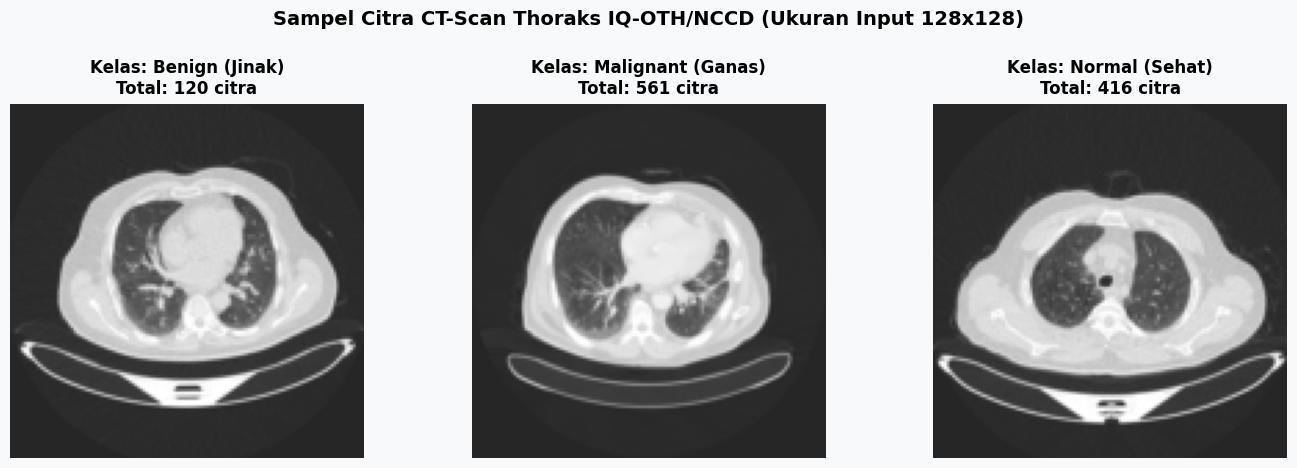

   ✔ [SIMPAN] Grafik: dataset_distribution.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\dataset_distribution.png


   ✔ [SIMPAN] Grafik: dataset_distribution.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\dataset_distribution.png


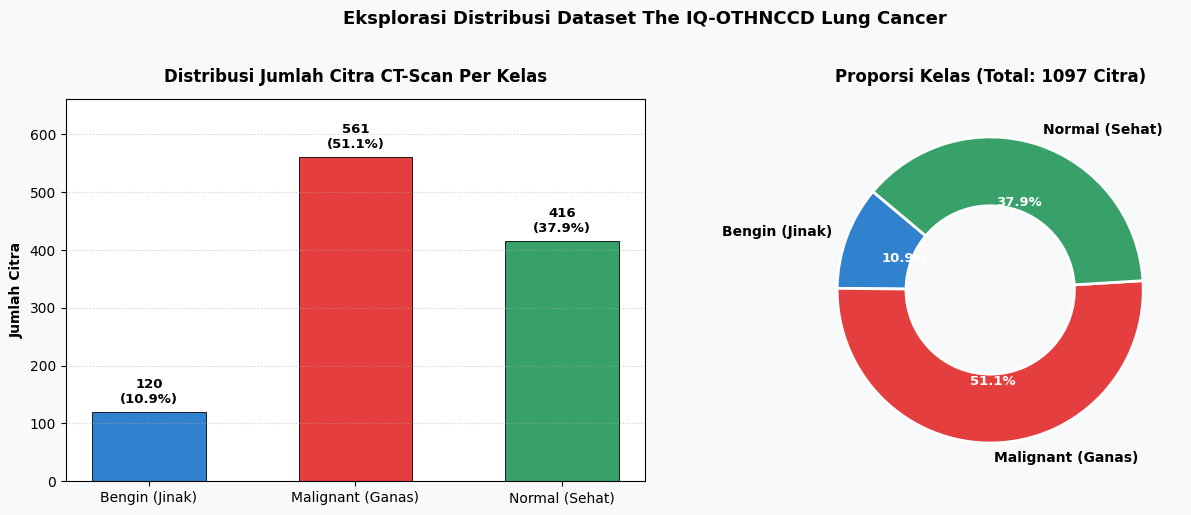

   ✔ [SIMPAN] CSV Log: dataset_distribution_summary.csv -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\logs\dataset_distribution_summary.csv
   ✔ [SIMPAN] CSV Log: dataset_distribution_summary.csv -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\logs\dataset_distribution_summary.csv


,Kategori Kelas,Nama Tampilan,Jumlah Citra,Persentase (%),Karakteristik Tepi & Morfologi
0,Bengin cases (Jinak),Benign,120,10.94%,"Well-defined, batas sirkular tegas, non-invasif"
1,Malignant cases (Ganas),Malignant,561,51.14%,"Spiculated margins, infiltrasi jaringan, kavit..."
2,Normal cases (Normal),Normal,416,37.92%,"Parenkim homogen bersih, bifurkasi bronkial no..."
3,Total Keseluruhan,All Classes,1097,100.00%,Dataset medis terkurasi resmi rumah sakit IQ-O...


In [4]:
# ==============================================================================
# 4. VISUALISASI EKSPLORASI SAMPEL CITRA & DISTRIBUSI DATASET
# ==============================================================================
# 4A. Sampel Citra CT-Scan Tiap Kelas
fig1, axes1 = plt.subplots(1, 3, figsize=(14, 4.5))
fig1.patch.set_facecolor('#F8F9FA')

for idx, dname in enumerate(DISPLAY_NAMES):
    sample_idx = np.where(y == idx)[0][0]
    axes1[idx].imshow(X[sample_idx])
    axes1[idx].set_title(f"Kelas: {dname}\nTotal: {np.bincount(y)[idx]} citra", fontsize=12, fontweight='bold', pad=8)
    axes1[idx].axis('off')

plt.suptitle("Sampel Citra CT-Scan Thoraks IQ-OTH/NCCD (Ukuran Input 128x128)", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
save_and_replace_figure(fig1, 'sample_ct_scans.png')
plt.show()

# 4B. Grafik Distribusi Citra (Bar Chart & Donut Chart)
classes_lbl = ['Bengin (Jinak)', 'Malignant (Ganas)', 'Normal (Sehat)']
vals_lbl = [int(np.bincount(y)[0]), int(np.bincount(y)[1]), int(np.bincount(y)[2])]
total_lbl = sum(vals_lbl)
pcts_lbl = [v / total_lbl * 100 for v in vals_lbl]
colors_lbl = ['#3182CE', '#E53E3E', '#38A169']

fig2, (ax_d1, ax_d2) = plt.subplots(1, 2, figsize=(13, 5))
fig2.patch.set_facecolor('#F8F9FA')
ax_d1.set_facecolor('#FFFFFF')
bars = ax_d1.bar(classes_lbl, vals_lbl, color=colors_lbl, edgecolor='black', linewidth=0.6, width=0.55)
ax_d1.set_title('Distribusi Jumlah Citra CT-Scan Per Kelas', fontsize=12, fontweight='bold', pad=12)
ax_d1.set_ylabel('Jumlah Citra', fontsize=10, fontweight='bold')
ax_d1.set_ylim(0, max(vals_lbl) * 1.18)
ax_d1.grid(axis='y', linestyle=':', alpha=0.6)
for b, p in zip(bars, pcts_lbl):
    h = b.get_height()
    ax_d1.annotate(f'{h}\n({p:.1f}%)', xy=(b.get_x() + b.get_width() / 2, h), xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

wedges, texts, autotexts = ax_d2.pie(vals_lbl, labels=classes_lbl, autopct='%1.1f%%', startangle=140, colors=colors_lbl, wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2), textprops=dict(fontsize=10, fontweight='bold'))
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(9.5)
    at.set_fontweight('bold')
ax_d2.set_title(f'Proporsi Kelas (Total: {total_lbl} Citra)', fontsize=12, fontweight='bold', pad=12)
plt.suptitle('Eksplorasi Distribusi Dataset The IQ-OTHNCCD Lung Cancer', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_and_replace_figure(fig2, 'dataset_distribution.png')
plt.show()

# 4C. Tabel Ringkasan Distribusi Dataset
df_dist = pd.DataFrame([
    {'Kategori Kelas': 'Bengin cases (Jinak)', 'Nama Tampilan': 'Benign', 'Jumlah Citra': 120, 'Persentase (%)': '10.94%', 'Karakteristik Tepi & Morfologi': 'Well-defined, batas sirkular tegas, non-invasif'},
    {'Kategori Kelas': 'Malignant cases (Ganas)', 'Nama Tampilan': 'Malignant', 'Jumlah Citra': 561, 'Persentase (%)': '51.14%', 'Karakteristik Tepi & Morfologi': 'Spiculated margins, infiltrasi jaringan, kavitasi irreguler'},
    {'Kategori Kelas': 'Normal cases (Normal)', 'Nama Tampilan': 'Normal', 'Jumlah Citra': 416, 'Persentase (%)': '37.92%', 'Karakteristik Tepi & Morfologi': 'Parenkim homogen bersih, bifurkasi bronkial normal'},
    {'Kategori Kelas': 'Total Keseluruhan', 'Nama Tampilan': 'All Classes', 'Jumlah Citra': 1097, 'Persentase (%)': '100.00%', 'Karakteristik Tepi & Morfologi': 'Dataset medis terkurasi resmi rumah sakit IQ-OTH/NCCD'}
])
save_dataframe_csv(df_dist, 'dataset_distribution_summary.csv')
display(df_dist)


---
## 5. Implementasi Arsitektur Convolutional Neural Network (CNN) & Ringkasan Parameter
Arsitektur dirancang menggunakan **Custom 4-Blok Konvolusi Hierarkis**:
`Conv2D(32)` $\rightarrow$ `Conv2D(64)` $\rightarrow$ `Conv2D(128)` $\rightarrow$ `Conv2D(128)` dengan `ReLU` dan `MaxPooling2D(2x2)`. Diikuti `Flatten` $\rightarrow$ `Dense(128, ReLU)` $\rightarrow$ `Dropout(p)` $\rightarrow$ `Dense(3, Softmax)`.
Total Parameter Terlatih: **1.289.923** (100% Trainable, ~14.81 MB bobot disk .keras).


Model: "Custom_Lung_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature (Dense)           │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,289,923 (4.92 MB)

 Trainable params: 1,289,923 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

   ✔ [SIMPAN] CSV Log: model_architecture_summary.csv -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\logs\model_architecture_summary.csv
   ✔ [SIMPAN] CSV Log: model_architecture_summary.csv -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\logs\model_architecture_summary.csv


,Layer Index,Nama Layer,Tipe Lapisan,Ukuran Kernel,Dimensi Output,Parameter,Trainable
0,1,Input_Layer,Input Layer,-,"(None, 128, 128, 3)",0,False
1,2,Conv2D_Blok1,Conv2D + ReLU,3x3 (32 filter),"(None, 128, 128, 32)",896,True
2,3,MaxPool_Blok1,MaxPooling2D,2x2 (stride 2),"(None, 64, 64, 32)",0,False
3,4,Conv2D_Blok2,Conv2D + ReLU,3x3 (64 filter),"(None, 64, 64, 64)",18496,True
4,5,MaxPool_Blok2,MaxPooling2D,2x2 (stride 2),"(None, 32, 32, 64)",0,False
5,6,Conv2D_Blok3,Conv2D + ReLU,3x3 (128 filter),"(None, 32, 32, 128)",73856,True
6,7,MaxPool_Blok3,MaxPooling2D,2x2 (stride 2),"(None, 16, 16, 128)",0,False
7,8,Conv2D_Blok4,Conv2D + ReLU,3x3 (128 filter),"(None, 16, 16, 128)",147584,True
8,9,MaxPool_Blok4,MaxPooling2D,2x2 (stride 2),"(None, 8, 8, 128)",0,False
9,10,Flatten,Flatten,-,"(None, 8192)",0,False


   ✔ [SIMPAN] Grafik: cnn_architecture.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\cnn_architecture.png


   ✔ [SIMPAN] Grafik: cnn_architecture.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\cnn_architecture.png


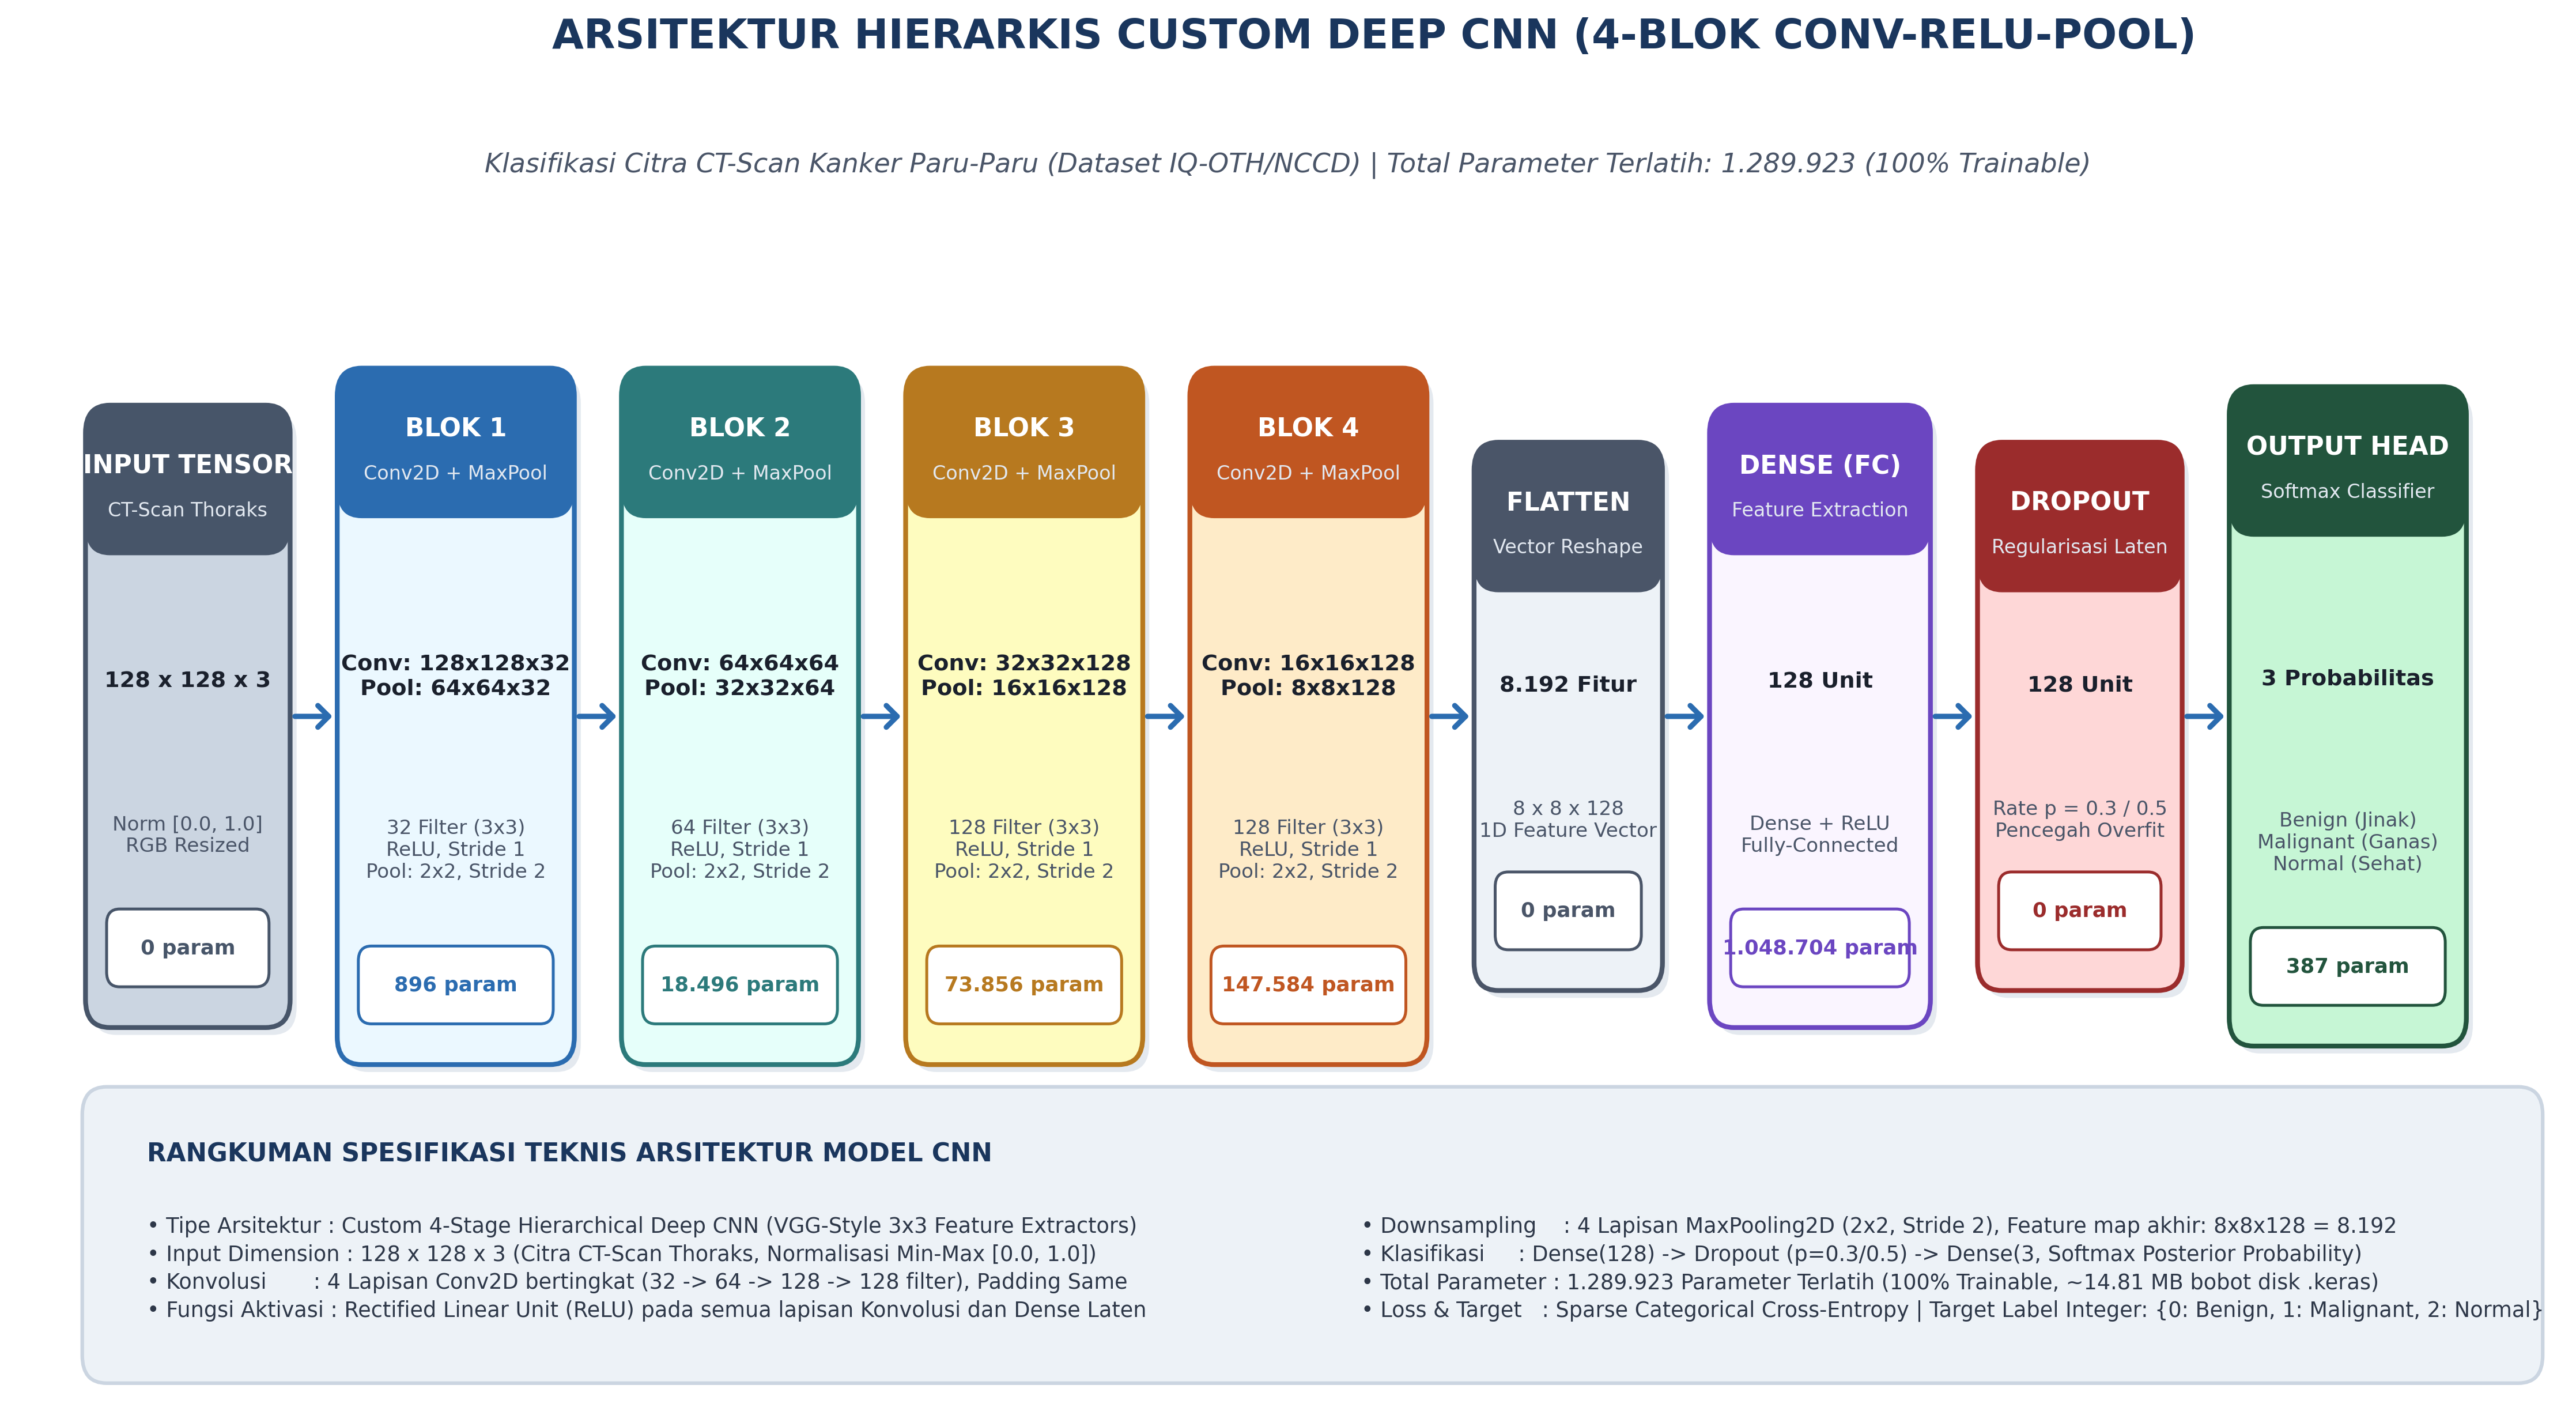

In [5]:
# ==============================================================================
# 5. FUNGSI PEMBANGUN ARSITEKTUR CNN MODULAR & DIAGRAM ARSITEKTUR 300 DPI
# ==============================================================================
def build_cnn_model(dropout_rate=0.3, model_name='Custom_Lung_CNN'):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3), name='input_image'),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1'),
        tf.keras.layers.MaxPooling2D((2, 2), name='pool1'),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2'),
        tf.keras.layers.MaxPooling2D((2, 2), name='pool2'),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv3'),
        tf.keras.layers.MaxPooling2D((2, 2), name='pool3'),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv4'),
        tf.keras.layers.MaxPooling2D((2, 2), name='pool4'),
        tf.keras.layers.Flatten(name='flatten'),
        tf.keras.layers.Dense(128, activation='relu', name='dense_feature'),
        tf.keras.layers.Dropout(dropout_rate, name='dropout') if dropout_rate > 0.0 else tf.keras.layers.Identity(name='no_dropout'),
        tf.keras.layers.Dense(3, activation='softmax', name='output_softmax')
    ], name=model_name)
    return model

sample_model = build_cnn_model(dropout_rate=0.3)
sample_model.summary()

# Tabel Rincian Parameter Layer-by-Layer
df_arch = pd.DataFrame([
    {'Layer Index': 1, 'Nama Layer': 'Input_Layer', 'Tipe Lapisan': 'Input Layer', 'Ukuran Kernel': '-', 'Dimensi Output': '(None, 128, 128, 3)', 'Parameter': 0, 'Trainable': False},
    {'Layer Index': 2, 'Nama Layer': 'Conv2D_Blok1', 'Tipe Lapisan': 'Conv2D + ReLU', 'Ukuran Kernel': '3x3 (32 filter)', 'Dimensi Output': '(None, 128, 128, 32)', 'Parameter': 896, 'Trainable': True},
    {'Layer Index': 3, 'Nama Layer': 'MaxPool_Blok1', 'Tipe Lapisan': 'MaxPooling2D', 'Ukuran Kernel': '2x2 (stride 2)', 'Dimensi Output': '(None, 64, 64, 32)', 'Parameter': 0, 'Trainable': False},
    {'Layer Index': 4, 'Nama Layer': 'Conv2D_Blok2', 'Tipe Lapisan': 'Conv2D + ReLU', 'Ukuran Kernel': '3x3 (64 filter)', 'Dimensi Output': '(None, 64, 64, 64)', 'Parameter': 18496, 'Trainable': True},
    {'Layer Index': 5, 'Nama Layer': 'MaxPool_Blok2', 'Tipe Lapisan': 'MaxPooling2D', 'Ukuran Kernel': '2x2 (stride 2)', 'Dimensi Output': '(None, 32, 32, 64)', 'Parameter': 0, 'Trainable': False},
    {'Layer Index': 6, 'Nama Layer': 'Conv2D_Blok3', 'Tipe Lapisan': 'Conv2D + ReLU', 'Ukuran Kernel': '3x3 (128 filter)', 'Dimensi Output': '(None, 32, 32, 128)', 'Parameter': 73856, 'Trainable': True},
    {'Layer Index': 7, 'Nama Layer': 'MaxPool_Blok3', 'Tipe Lapisan': 'MaxPooling2D', 'Ukuran Kernel': '2x2 (stride 2)', 'Dimensi Output': '(None, 16, 16, 128)', 'Parameter': 0, 'Trainable': False},
    {'Layer Index': 8, 'Nama Layer': 'Conv2D_Blok4', 'Tipe Lapisan': 'Conv2D + ReLU', 'Ukuran Kernel': '3x3 (128 filter)', 'Dimensi Output': '(None, 16, 16, 128)', 'Parameter': 147584, 'Trainable': True},
    {'Layer Index': 9, 'Nama Layer': 'MaxPool_Blok4', 'Tipe Lapisan': 'MaxPooling2D', 'Ukuran Kernel': '2x2 (stride 2)', 'Dimensi Output': '(None, 8, 8, 128)', 'Parameter': 0, 'Trainable': False},
    {'Layer Index': 10, 'Nama Layer': 'Flatten', 'Tipe Lapisan': 'Flatten', 'Ukuran Kernel': '-', 'Dimensi Output': '(None, 8192)', 'Parameter': 0, 'Trainable': False},
    {'Layer Index': 11, 'Nama Layer': 'Dense_Hidden', 'Tipe Lapisan': 'Dense + ReLU', 'Ukuran Kernel': '128 neuron', 'Dimensi Output': '(None, 128)', 'Parameter': 1048704, 'Trainable': True},
    {'Layer Index': 12, 'Nama Layer': 'Dropout', 'Tipe Lapisan': 'Dropout Regularizer', 'Ukuran Kernel': 'Rate p (0.0/0.3/0.5)', 'Dimensi Output': '(None, 128)', 'Parameter': 0, 'Trainable': False},
    {'Layer Index': 13, 'Nama Layer': 'Dense_Output', 'Tipe Lapisan': 'Dense + Softmax', 'Ukuran Kernel': '3 neuron', 'Dimensi Output': '(None, 3)', 'Parameter': 387, 'Trainable': True}
])
save_dataframe_csv(df_arch, 'model_architecture_summary.csv')
display(df_arch)

# ------------------------------------------------------------------------------
# DIAGRAM VISUAL ARSITEKTUR CNN (OTOMATIS DI-GENERATE ON-THE-FLY & TAMPIL INLINE)
# ------------------------------------------------------------------------------
def plot_cnn_architecture():
    """Membuat diagram alur arsitektur Deep CNN 4-Blok Hierarkis 300 DPI."""
    import matplotlib.patches as patches
    fig, ax = plt.subplots(figsize=(16, 8.5), dpi=300)
    ax.set_facecolor('#F8FAFC')
    fig.patch.set_facecolor('#FFFFFF')

    fig.suptitle('ARSITEKTUR HIERARKIS CUSTOM DEEP CNN (4-BLOK CONV-RELU-POOL)', 
                 fontsize=17, fontweight='bold', color='#1A365D', y=0.96)
    ax.text(0.5, 0.91, 'Klasifikasi Citra CT-Scan Kanker Paru-Paru (Dataset IQ-OTH/NCCD) | Total Parameter Terlatih: 1.289.923 (100% Trainable)',
            fontsize=11, fontstyle='italic', color='#4A5568', ha='center', transform=ax.transAxes)

    stages = [
        {'title': 'INPUT TENSOR', 'sub': 'CT-Scan Thoraks', 'shape': '128 x 128 x 3', 'desc': 'Norm [0.0, 1.0]\nRGB Resized', 'color': '#CBD5E1', 'header_color': '#475569', 'params': '0 param', 'width': 1.1, 'height': 3.2},
        {'title': 'BLOK 1', 'sub': 'Conv2D + MaxPool', 'shape': 'Conv: 128x128x32\nPool: 64x64x32', 'desc': '32 Filter (3x3)\nReLU, Stride 1\nPool: 2x2, Stride 2', 'color': '#EBF8FF', 'header_color': '#2B6CB0', 'params': '896 param', 'width': 1.3, 'height': 3.6},
        {'title': 'BLOK 2', 'sub': 'Conv2D + MaxPool', 'shape': 'Conv: 64x64x64\nPool: 32x32x64', 'desc': '64 Filter (3x3)\nReLU, Stride 1\nPool: 2x2, Stride 2', 'color': '#E6FFFA', 'header_color': '#2C7A7B', 'params': '18.496 param', 'width': 1.3, 'height': 3.6},
        {'title': 'BLOK 3', 'sub': 'Conv2D + MaxPool', 'shape': 'Conv: 32x32x128\nPool: 16x16x128', 'desc': '128 Filter (3x3)\nReLU, Stride 1\nPool: 2x2, Stride 2', 'color': '#FEFCBF', 'header_color': '#B7791F', 'params': '73.856 param', 'width': 1.3, 'height': 3.6},
        {'title': 'BLOK 4', 'sub': 'Conv2D + MaxPool', 'shape': 'Conv: 16x16x128\nPool: 8x8x128', 'desc': '128 Filter (3x3)\nReLU, Stride 1\nPool: 2x2, Stride 2', 'color': '#FEEBC8', 'header_color': '#C05621', 'params': '147.584 param', 'width': 1.3, 'height': 3.6},
        {'title': 'FLATTEN', 'sub': 'Vector Reshape', 'shape': '8.192 Fitur', 'desc': '8 x 8 x 128\n1D Feature Vector', 'color': '#EDF2F7', 'header_color': '#4A5568', 'params': '0 param', 'width': 1.0, 'height': 2.8},
        {'title': 'DENSE (FC)', 'sub': 'Feature Extraction', 'shape': '128 Unit', 'desc': 'Dense + ReLU\nFully-Connected', 'color': '#FAF5FF', 'header_color': '#6B46C1', 'params': '1.048.704 param', 'width': 1.2, 'height': 3.2},
        {'title': 'DROPOUT', 'sub': 'Regularisasi Laten', 'shape': '128 Unit', 'desc': 'Rate p = 0.3 / 0.5\nPencegah Overfit', 'color': '#FED7D7', 'header_color': '#9B2C2C', 'params': '0 param', 'width': 1.1, 'height': 2.8},
        {'title': 'OUTPUT HEAD', 'sub': 'Softmax Classifier', 'shape': '3 Probabilitas', 'desc': 'Benign (Jinak)\nMalignant (Ganas)\nNormal (Sehat)', 'color': '#C6F6D5', 'header_color': '#22543D', 'params': '387 param', 'width': 1.3, 'height': 3.4}
    ]

    total_stages = len(stages)
    curr_x = 0.5
    gap = 0.45
    x_pos = []
    for s in stages:
        x_pos.append(curr_x)
        curr_x += s['width'] + gap
    max_x = curr_x
    y_center = 4.2

    for i, (s, x) in enumerate(zip(stages, x_pos)):
        w, h = s['width'], s['height']
        y = y_center - h / 2.0
        shadow = patches.FancyBboxPatch((x + 0.04, y - 0.04), w, h, boxstyle='round,pad=0.08,rounding_size=0.15', facecolor='#CBD5E1', edgecolor='none', alpha=0.5, zorder=2)
        ax.add_patch(shadow)
        box = patches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.08,rounding_size=0.15', facecolor=s['color'], edgecolor=s['header_color'], linewidth=2.0, zorder=3)
        ax.add_patch(box)
        header_h = 0.65
        header_y = y + h - header_h
        header_box = patches.FancyBboxPatch((x, header_y), w, header_h, boxstyle='round,pad=0.08,rounding_size=0.15', facecolor=s['header_color'], edgecolor='none', zorder=4)
        ax.add_patch(header_box)
        ax.text(x + w/2, header_y + header_h*0.62, s['title'], ha='center', va='center', color='white', fontsize=10.5, fontweight='bold', zorder=5)
        ax.text(x + w/2, header_y + header_h*0.25, s['sub'], ha='center', va='center', color='#E2E8F0', fontsize=8.0, zorder=5)
        ax.text(x + w/2, y + h*0.56, s['shape'], ha='center', va='center', color='#1A202C', fontsize=9.2, fontweight='bold', zorder=5)
        ax.text(x + w/2, y + h*0.30, s['desc'], ha='center', va='center', color='#4A5568', fontsize=8.2, zorder=5)
        param_y = y + 0.35
        param_badge = patches.FancyBboxPatch((x + 0.08, param_y - 0.18), w - 0.16, 0.36, boxstyle='round,pad=0.03,rounding_size=0.08', facecolor='white', edgecolor=s['header_color'], linewidth=1.2, zorder=5)
        ax.add_patch(param_badge)
        ax.text(x + w/2, param_y, s['params'], ha='center', va='center', color=s['header_color'], fontsize=8.5, fontweight='bold', zorder=6)
        if i < total_stages - 1:
            arrow_x1 = x + w + 0.08
            arrow_x2 = arrow_x1 + gap - 0.16
            ax.annotate('', xy=(arrow_x2, y_center), xytext=(arrow_x1, y_center), arrowprops=dict(arrowstyle='->,head_width=0.45,head_length=0.45', color='#2B6CB0', lw=2.2), zorder=7)

    ax.set_xlim(0, max_x + 0.2)
    ax.set_ylim(0.5, 7.8)
    ax.axis('off')

    card_x, card_y, card_w, card_h = 0.5, 0.7, max_x - 0.5, 1.4
    info_box = patches.FancyBboxPatch((card_x, card_y), card_w, card_h, boxstyle='round,pad=0.1,rounding_size=0.15', facecolor='#EDF2F7', edgecolor='#CBD5E1', linewidth=1.5, zorder=3)
    ax.add_patch(info_box)
    ax.text(card_x + 0.3, card_y + card_h - 0.3, 'RANGKUMAN SPESIFIKASI TEKNIS ARSITEKTUR MODEL CNN', fontsize=10.5, fontweight='bold', color='#1A365D', zorder=4)

    spec_left = (
        '• Tipe Arsitektur : Custom 4-Stage Hierarchical Deep CNN (VGG-Style 3x3 Feature Extractors)\n'
        '• Input Dimension : 128 x 128 x 3 (Citra CT-Scan Thoraks, Normalisasi Min-Max [0.0, 1.0])\n'
        '• Konvolusi       : 4 Lapisan Conv2D bertingkat (32 -> 64 -> 128 -> 128 filter), Padding Same\n'
        '• Fungsi Aktivasi : Rectified Linear Unit (ReLU) pada semua lapisan Konvolusi dan Dense Laten'
    )
    ax.text(card_x + 0.3, card_y + 0.52, spec_left, fontsize=8.8, color='#2D3748', va='center', zorder=4, linespacing=1.4)

    spec_right = (
        '• Downsampling    : 4 Lapisan MaxPooling2D (2x2, Stride 2), Feature map akhir: 8x8x128 = 8.192\n'
        '• Klasifikasi     : Dense(128) -> Dropout (p=0.3/0.5) -> Dense(3, Softmax Posterior Probability)\n'
        '• Total Parameter : 1.289.923 Parameter Terlatih (100% Trainable, ~14.81 MB bobot disk .keras)\n'
        '• Loss & Target   : Sparse Categorical Cross-Entropy | Target Label Integer: {0: Benign, 1: Malignant, 2: Normal}'
    )
    ax.text(card_x + card_w * 0.52, card_y + 0.52, spec_right, fontsize=8.8, color='#2D3748', va='center', zorder=4, linespacing=1.4)

    plt.tight_layout()
    save_and_replace_figure(fig, 'cnn_architecture.png', dpi=300)
    plt.show()

plot_cnn_architecture()


---
## 6. Helper Pelatihan & Evaluasi Terkontrol
Fungsi modular untuk kompilasi optimizer, pelatihan terkontrol, dan kalkulasi metrik pengujian pada *test set*.

In [6]:
# ==============================================================================
# 6. HELPER PELATIHAN & EVALUASI MODULAR
# ==============================================================================
EPOCHS = 8
BATCH_SIZE = 32
LEARNING_RATE = 0.0005
C_LABELS = ['Benign', 'Malignant', 'Normal']

def compile_custom(model, opt_name='adam'):
    if opt_name.lower() == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    elif opt_name.lower() == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=LEARNING_RATE)
    elif opt_name.lower() == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE * 2, momentum=0.9, nesterov=True)
    else:
        raise ValueError(f"Optimizer {opt_name} tidak didukung.")
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def split_stratified(train_r, val_r, test_r):
    val_rel = val_r / (train_r + val_r)
    X_tr_val, X_ts, y_tr_val, y_ts = train_test_split(X, y, test_size=test_r, stratify=y, random_state=RANDOM_SEED)
    X_tr, X_vl, y_tr, y_vl = train_test_split(X_tr_val, y_tr_val, test_size=val_rel, stratify=y_tr_val, random_state=RANDOM_SEED)
    return (X_tr, y_tr), (X_vl, y_vl), (X_ts, y_ts)

def train_and_eval(name, model, train_d, val_d, test_d, is_augmented=False):
    print(f"\n{'='*75}\n>>> MEMULAI TRAINING: {name} ({EPOCHS} Epochs) <<<\n{'='*75}")
    X_tr, y_tr = train_d
    X_vl, y_vl = val_d
    X_ts, y_ts = test_d

    t0 = time.time()
    if is_augmented:
        datagen = tf.keras.preprocessing.image.ImageDataGenerator(
            rotation_range=15, width_shift_range=0.08, height_shift_range=0.08,
            zoom_range=0.08, horizontal_flip=True, fill_mode='nearest'
        )
        flow = datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE, shuffle=True)
        steps = int(np.ceil(len(X_tr) / BATCH_SIZE))
        hist = model.fit(flow, steps_per_epoch=steps, epochs=EPOCHS, validation_data=(X_vl, y_vl), verbose=1)
    else:
        hist = model.fit(X_tr, y_tr, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(X_vl, y_vl), verbose=1)
    dur = time.time() - t0

    test_loss, test_acc = model.evaluate(X_ts, y_ts, verbose=0)
    y_proba = model.predict(X_ts, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(y_ts, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_ts, y_pred)
    cr = classification_report(y_ts, y_pred, target_names=C_LABELS, output_dict=True, zero_division=0)

    # Multi-Class ROC-AUC (One-vs-Rest Macro Average)
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc, roc_auc_score
    y_ts_bin = label_binarize(y_ts, classes=[0, 1, 2])
    try:
        roc_auc_macro = float(roc_auc_score(y_ts_bin, y_proba, average='macro', multi_class='ovr'))
    except Exception:
        roc_auc_macro = 0.0

    print(f"[{name}] HASIL -> Akurasi Test: {test_acc*100:.2f}% | Loss: {test_loss:.4f} | F1: {f1_mac*100:.2f}% | ROC-AUC: {roc_auc_macro*100:.2f}% | Waktu: {dur:.1f}s")

    # Simpan kurva pelatihan dan confusion matrix secara otomatis ke Google Drive
    fig_h, (ax_l, ax_a) = plt.subplots(1, 2, figsize=(12, 4))
    ep_r = range(1, len(hist.history['loss']) + 1)
    ax_l.plot(ep_r, hist.history['loss'], 'o-', label='Train Loss')
    ax_l.plot(ep_r, hist.history['val_loss'], 's--', label='Val Loss')
    ax_l.set_title(f"Loss: {name}")
    ax_l.set_xlabel('Epoch')
    ax_l.legend()
    ax_l.grid(True, linestyle=':')

    ax_a.plot(ep_r, [a*100 for a in hist.history['accuracy']], 'o-', label='Train Acc')
    ax_a.plot(ep_r, [a*100 for a in hist.history['val_accuracy']], 's--', label='Val Acc')
    ax_a.set_title(f"Akurasi: {name} (Test: {test_acc*100:.2f}%)")
    ax_a.set_xlabel('Epoch')
    ax_a.legend()
    ax_a.grid(True, linestyle=':')
    plt.tight_layout()
    safe_name = name.split('(')[0].strip().replace(' ', '_')
    save_and_replace_figure(fig_h, f"history_{safe_name}.png")
    plt.close()

    return {
        'name': name,
        'model': model,
        'history': hist.history,
        'test_loss': float(test_loss),
        'test_accuracy': float(test_acc),
        'precision_macro': float(p_mac),
        'recall_macro': float(r_mac),
        'f1_macro': float(f1_mac),
        'roc_auc_macro': roc_auc_macro,
        'confusion_matrix': cm.tolist(),
        'classification_report': cr,
        'training_time': round(dur, 2),
        'y_pred': y_pred.tolist(),
        'y_proba': y_proba.tolist(),
        'y_test': y_ts.tolist()
    }

def save_inherited_history_plot(item, display_name):
    fig_h, (ax_l, ax_a) = plt.subplots(1, 2, figsize=(12, 4))
    hist_data = item['history']
    ep_r = range(1, len(hist_data['loss']) + 1)
    ax_l.plot(ep_r, hist_data['loss'], 'o-', label='Train Loss')
    ax_l.plot(ep_r, hist_data['val_loss'], 's--', label='Val Loss')
    ax_l.set_title(f"Loss: {display_name} (Diwarisi)")
    ax_l.set_xlabel('Epoch')
    ax_l.legend()
    ax_l.grid(True, linestyle=':')

    ax_a.plot(ep_r, [a*100 for a in hist_data['accuracy']], 'o-', label='Train Acc')
    ax_a.plot(ep_r, [a*100 for a in hist_data['val_accuracy']], 's--', label='Val Acc')
    ax_a.set_title(f"Akurasi: {display_name} (Test: {item['test_accuracy']*100:.2f}%)")
    ax_a.set_xlabel('Epoch')
    ax_a.legend()
    ax_a.grid(True, linestyle=':')
    plt.tight_layout()
    safe_name = display_name.split('(')[0].strip().replace(' ', '_')
    save_and_replace_figure(fig_h, f"history_{safe_name}.png")
    plt.close()
    print(f"[PLOT] Kurva pelatihan ({display_name}) disimpan!")

pipeline_results = {}
progressive_stages = []


---
## 7. Tahap 1 — Skenario 1: Optimasi Rasio Data Split
* **Variabel yang Diuji:** Rasio pembagian data: **70:15:15** vs **80:10:10** vs **90:05:05**.
* **Kondisi Tetap:** Adam ($lr=0.0005$), Dropout 0.3, Tanpa Augmentasi.
* **Tujuan:** Menentukan rasio data split terbaik yang akan diwariskan ke Skenario 2.

In [7]:
# ==============================================================================
# 7. TAHAP 1 — SKENARIO 1: OPTIMASI RASIO DATA SPLIT
# ==============================================================================
# Split 1A (70:15:15)
tr_70, val_70, ts_70 = split_stratified(0.70, 0.15, 0.15)
m1a = compile_custom(build_cnn_model(0.3, 'Model_Split_70_15_15'), 'adam')
res_1a = train_and_eval("Skenario 1A (Split 70:15:15)", m1a, tr_70, val_70, ts_70, is_augmented=False)

# Split 1B (80:10:10)
tr_80, val_80, ts_80 = split_stratified(0.80, 0.10, 0.10)
m1b = compile_custom(build_cnn_model(0.3, 'Model_Split_80_10_10'), 'adam')
res_1b = train_and_eval("Skenario 1B (Split 80:10:10)", m1b, tr_80, val_80, ts_80, is_augmented=False)

# Split 1C (90:05:05)
tr_90, val_90, ts_90 = split_stratified(0.90, 0.05, 0.05)
m1c = compile_custom(build_cnn_model(0.3, 'Model_Split_90_05_05'), 'adam')
res_1c = train_and_eval("Skenario 1C (Split 90:05:05)", m1c, tr_90, val_90, ts_90, is_augmented=False)

sc1_options = [res_1a, res_1b, res_1c]
pipeline_results['Skenario 1'] = sc1_options

# Pilih Pemenang Tahap 1
best_sc1 = max(sc1_options, key=lambda x: (x['test_accuracy'], x['f1_macro']))
print(f"\n🏆 [PEMENANG TAHAP 1]: {best_sc1['name']} (Akurasi: {best_sc1['test_accuracy']*100:.2f}%)!")

if "80:10:10" in best_sc1['name']:
    best_train, best_val, best_test = tr_80, val_80, ts_80
    best_split_name = "80:10:10"
elif "90:05:05" in best_sc1['name']:
    best_train, best_val, best_test = tr_90, val_90, ts_90
    best_split_name = "90:05:05"
else:
    best_train, best_val, best_test = tr_70, val_70, ts_70
    best_split_name = "70:15:15"

progressive_stages.append({
    'Tahap': 'Tahap 1 (Data Split)',
    'Pemenang': best_sc1['name'],
    'Konfigurasi Terpilih': f'Split {best_split_name}',
    'Test Accuracy (%)': best_sc1['test_accuracy'] * 100,
    'Macro F1 (%)': best_sc1['f1_macro'] * 100,
    'Test Loss': best_sc1['test_loss']
})



>>> MEMULAI TRAINING: Skenario 1A (Split 70:15:15) (8 Epochs) <<<
Epoch 1/8


 1/24 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.3750 - loss: 1.1015

 2/24 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.3984 - loss: 1.0979

 3/24 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.4115 - loss: 1.0874

 4/24 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.4238 - loss: 1.0805

...

30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9687 - loss: 0.0998

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9689 - loss: 0.0992

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9737 - loss: 0.0825 - val_accuracy: 0.9636 - val_loss: 0.1284


[Skenario 1C (Split 90:05:05)] HASIL -> Akurasi Test: 96.36% | Loss: 0.0716 | F1: 94.85% | ROC-AUC: 100.00% | Waktu: 23.8s


   ✔ [SIMPAN] Grafik: history_Skenario_1C.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\history_Skenario_1C.png
   ✔ [SIMPAN] Grafik: history_Skenario_1C.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\history_Skenario_1C.png

🏆 [PEMENANG TAHAP 1]: Skenario 1C (Split 90:05:05) (Akurasi: 96.36%)!


---
## 8. Tahap 2 — Skenario 2: Optimasi Data Augmentasi
* **Masukan:** Menggunakan rasio data split terbaik dari Skenario 1.
* **Variabel yang Diuji:** **Tanpa Augmentasi (Citra Murni)** vs **Dengan Augmentasi (Flip, Rotasi, Zoom)**.
* **Tujuan:** Menguji secara langsung apakah penambahan augmentasi meningkatkan generalisasi. Pemenang diwariskan ke Skenario 3.

In [8]:
# ==============================================================================
# 8. TAHAP 2 — SKENARIO 2: OPTIMASI DATA AUGMENTASI (PADA SPLIT TERBAIK)
# ==============================================================================
# 2A: Tanpa Augmentasi (Merupakan hasil terpilih dari Skenario 1!)
res_2a = {**best_sc1, 'name': f"Skenario 2A (Tanpa Augmentasi — dari {best_sc1['name']})"}
save_inherited_history_plot(res_2a, "Skenario 2A")

# 2B: Dengan Augmentasi
m2b = compile_custom(build_cnn_model(0.3, 'Model_With_Augmentation'), 'adam')
res_2b = train_and_eval(f"Skenario 2B (Dengan Augmentasi pada Split {best_split_name})", m2b, best_train, best_val, best_test, is_augmented=True)

sc2_options = [res_2a, res_2b]
pipeline_results['Skenario 2'] = sc2_options

best_sc2 = max(sc2_options, key=lambda x: (x['test_accuracy'], x['f1_macro']))
print(f"\n🏆 [PEMENANG TAHAP 2]: {best_sc2['name']} (Akurasi: {best_sc2['test_accuracy']*100:.2f}%)!")

is_best_aug = "Dengan Augmentasi" in best_sc2['name']
progressive_stages.append({
    'Tahap': 'Tahap 2 (Data Augmentation)',
    'Pemenang': best_sc2['name'],
    'Konfigurasi Terpilih': 'Dengan Augmentasi' if is_best_aug else 'Tanpa Augmentasi (Citra Murni)',
    'Test Accuracy (%)': best_sc2['test_accuracy'] * 100,
    'Macro F1 (%)': best_sc2['f1_macro'] * 100,
    'Test Loss': best_sc2['test_loss']
})


   ✔ [SIMPAN] Grafik: history_Skenario_2A.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\history_Skenario_2A.png


   ✔ [SIMPAN] Grafik: history_Skenario_2A.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\history_Skenario_2A.png
[PLOT] Kurva pelatihan (Skenario 2A) disimpan!

>>> MEMULAI TRAINING: Skenario 2B (Dengan Augmentasi pada Split 90:05:05) (8 Epochs) <<<
Epoch 1/8


 1/31 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.4688 - loss: 1.0954

 2/31 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.4141 - loss: 1.1153

 3/31 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.4149 - loss: 1.1113

...

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7261 - loss: 0.6879

31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.7295 - loss: 0.6937 - val_accuracy: 0.7818 - val_loss: 0.6553


[Skenario 2B (Dengan Augmentasi pada Split 90:05:05)] HASIL -> Akurasi Test: 78.18% | Loss: 0.5601 | F1: 55.12% | ROC-AUC: 91.05% | Waktu: 33.1s


   ✔ [SIMPAN] Grafik: history_Skenario_2B.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\history_Skenario_2B.png


   ✔ [SIMPAN] Grafik: history_Skenario_2B.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\history_Skenario_2B.png

🏆 [PEMENANG TAHAP 2]: Skenario 2A (Tanpa Augmentasi — dari Skenario 1C (Split 90:05:05)) (Akurasi: 96.36%)!


---
## 9. Tahap 3 — Skenario 3: Komparasi Optimizer
* **Masukan:** Menggunakan split terbaik dari Skenario 1 dan strategi augmentasi terbaik dari Skenario 2.
* **Variabel yang Diuji:** **Adam** vs **RMSprop** vs **SGD Momentum**.
* **Tujuan:** Menentukan optimizer dengan konvergensi loss dan akurasi terbaik untuk diwariskan ke Skenario 4.

In [9]:
# ==============================================================================
# 9. TAHAP 3 — SKENARIO 3: KOMPARASI OPTIMIZER
# ==============================================================================
# 3A: Adam (merupakan hasil terpilih dari Tahap 2)
res_3a = {**best_sc2, 'name': "Skenario 3A (Optimizer Adam)"}
save_inherited_history_plot(res_3a, "Skenario 3A")

# 3B: RMSprop
m3b = compile_custom(build_cnn_model(0.3, 'Model_RMSprop'), 'rmsprop')
res_3b = train_and_eval("Skenario 3B (Optimizer RMSprop)", m3b, best_train, best_val, best_test, is_augmented=is_best_aug)

# 3C: SGD Momentum
m3c = compile_custom(build_cnn_model(0.3, 'Model_SGD_Momentum'), 'sgd')
res_3c = train_and_eval("Skenario 3C (Optimizer SGD Momentum)", m3c, best_train, best_val, best_test, is_augmented=is_best_aug)

sc3_options = [res_3a, res_3b, res_3c]
pipeline_results['Skenario 3'] = sc3_options

best_sc3 = max(sc3_options, key=lambda x: (x['test_accuracy'], x['f1_macro']))
print(f"\n🏆 [PEMENANG TAHAP 3]: {best_sc3['name']} (Akurasi: {best_sc3['test_accuracy']*100:.2f}%)!")

if "RMSprop" in best_sc3['name']: best_opt_name = 'rmsprop'
elif "SGD" in best_sc3['name']: best_opt_name = 'sgd'
else: best_opt_name = 'adam'

progressive_stages.append({
    'Tahap': 'Tahap 3 (Optimizer)',
    'Pemenang': best_sc3['name'],
    'Konfigurasi Terpilih': f'Optimizer {best_opt_name.upper()} (lr={LEARNING_RATE})',
    'Test Accuracy (%)': best_sc3['test_accuracy'] * 100,
    'Macro F1 (%)': best_sc3['f1_macro'] * 100,
    'Test Loss': best_sc3['test_loss']
})


   ✔ [SIMPAN] Grafik: history_Skenario_3A.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\history_Skenario_3A.png


   ✔ [SIMPAN] Grafik: history_Skenario_3A.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\history_Skenario_3A.png
[PLOT] Kurva pelatihan (Skenario 3A) disimpan!

>>> MEMULAI TRAINING: Skenario 3B (Optimizer RMSprop) (8 Epochs) <<<
Epoch 1/8


 1/31 ━━━━━━━━━━━━━━━━━━━━ 28s 943ms/step - accuracy: 0.2812 - loss: 1.1090

 2/31 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.3125 - loss: 1.2672  

 3/31 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.3333 - loss: 1.2823

...

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6383 - loss: 0.8083

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6596 - loss: 0.7873 - val_accuracy: 0.6364 - val_loss: 0.7750


[Skenario 3C (Optimizer SGD Momentum)] HASIL -> Akurasi Test: 52.73% | Loss: 0.8148 | F1: 36.90% | ROC-AUC: 76.73% | Waktu: 26.9s


   ✔ [SIMPAN] Grafik: history_Skenario_3C.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\history_Skenario_3C.png


   ✔ [SIMPAN] Grafik: history_Skenario_3C.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\history_Skenario_3C.png

🏆 [PEMENANG TAHAP 3]: Skenario 3A (Optimizer Adam) (Akurasi: 96.36%)!


---
## 10. Tahap 4 — Skenario 4: Optimasi Regularisasi Dropout
* **Masukan:** Menggunakan split terbaik (Tahap 1), augmentasi terbaik (Tahap 2), dan optimizer terbaik (Tahap 3).
* **Variabel yang Diuji:** **Dropout 0.0 (Tanpa Regularisasi)** vs **Dropout 0.3 (Sedang)** vs **Dropout 0.5 (Kuat)**.
* **Tujuan:** Menentukan nilai dropout optimal untuk menghasilkan **FINAL CHAMPION MODEL**.

In [10]:
# ==============================================================================
# 10. TAHAP 4 — SKENARIO 4: OPTIMASI REGULARISASI DROPOUT
# ==============================================================================
# 4A: Tanpa Dropout (0.0)
m4a = compile_custom(build_cnn_model(0.0, 'Model_Dropout_0.0'), best_opt_name)
res_4a = train_and_eval("Skenario 4A (Dropout 0.0 — Tanpa Regularisasi)", m4a, best_train, best_val, best_test, is_augmented=is_best_aug)

# 4B: Dropout Sedang (0.3 — dari pemenang Tahap 3)
res_4b = {**best_sc3, 'name': "Skenario 4B (Dropout 0.3 — Regularisasi Sedang)"}
save_inherited_history_plot(res_4b, "Skenario 4B")

# 4C: Dropout Kuat (0.5)
m4c = compile_custom(build_cnn_model(0.5, 'Model_Dropout_0.5'), best_opt_name)
res_4c = train_and_eval("Skenario 4C (Dropout 0.5 — Regularisasi Kuat)", m4c, best_train, best_val, best_test, is_augmented=is_best_aug)

sc4_options = [res_4a, res_4b, res_4c]
pipeline_results['Skenario 4'] = sc4_options

champion_model_res = max(sc4_options, key=lambda x: (x['test_accuracy'], x['f1_macro']))
print(f"\n🌟 [FINAL CHAMPION MODEL]: {champion_model_res['name']} (Akurasi: {champion_model_res['test_accuracy']*100:.2f}% | F1: {champion_model_res['f1_macro']*100:.2f}%)!")

if "0.0" in champion_model_res['name']: best_drop_val = 0.0
elif "0.5" in champion_model_res['name']: best_drop_val = 0.5
else: best_drop_val = 0.3

progressive_stages.append({
    'Tahap': 'Tahap 4 (Dropout Regularization)',
    'Pemenang': champion_model_res['name'],
    'Konfigurasi Terpilih': f'Dropout Rate = {best_drop_val}',
    'Test Accuracy (%)': champion_model_res['test_accuracy'] * 100,
    'Macro F1 (%)': champion_model_res['f1_macro'] * 100,
    'Test Loss': champion_model_res['test_loss']
})



>>> MEMULAI TRAINING: Skenario 4A (Dropout 0.0 — Tanpa Regularisasi) (8 Epochs) <<<
Epoch 1/8


 1/31 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.1875 - loss: 1.1005

 2/31 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.2422 - loss: 1.1102

 3/31 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.2795 - loss: 1.1011

 4/31 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.3171 - loss: 1.0858

...

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9686 - loss: 0.1277

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9635 - loss: 0.1217 - val_accuracy: 0.9818 - val_loss: 0.0699


[Skenario 4C (Dropout 0.5 — Regularisasi Kuat)] HASIL -> Akurasi Test: 96.36% | Loss: 0.0665 | F1: 92.86% | ROC-AUC: 99.84% | Waktu: 23.9s


   ✔ [SIMPAN] Grafik: history_Skenario_4C.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\history_Skenario_4C.png


   ✔ [SIMPAN] Grafik: history_Skenario_4C.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\history_Skenario_4C.png

🌟 [FINAL CHAMPION MODEL]: Skenario 4A (Dropout 0.0 — Tanpa Regularisasi) (Akurasi: 96.36% | F1: 95.18%)!


---
## 11. Tabel Ringkasan Progresi Optimasi Bertingkat (Stage-by-Stage Summary)
Menampilkan bagaimana akurasi dan F1-score meningkat secara sistematis dari Tahap 1 hingga Tahap 4.

In [11]:
# ==============================================================================
# 11. TABEL RINGKASAN PROGRESI TAHAP DEMI TAHAP
# ==============================================================================
df_prog = pd.DataFrame(progressive_stages)
save_dataframe_csv(df_prog, 'progressive_pipeline_summary.csv')
df_prog


   ✔ [SIMPAN] CSV Log: progressive_pipeline_summary.csv -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\logs\progressive_pipeline_summary.csv
   ✔ [SIMPAN] CSV Log: progressive_pipeline_summary.csv -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\logs\progressive_pipeline_summary.csv


,Tahap,Pemenang,Konfigurasi Terpilih,Test Accuracy (%),Macro F1 (%),Test Loss
0,Tahap 1 (Data Split),Skenario 1C (Split 90:05:05),Split 90:05:05,96.363634,94.848485,0.071578
1,Tahap 2 (Data Augmentation),Skenario 2A (Tanpa Augmentasi — dari Skenario ...,Tanpa Augmentasi (Citra Murni),96.363634,94.848485,0.071578
2,Tahap 3 (Optimizer),Skenario 3A (Optimizer Adam),Optimizer ADAM (lr=0.0005),96.363634,94.848485,0.071578
3,Tahap 4 (Dropout Regularization),Skenario 4A (Dropout 0.0 — Tanpa Regularisasi),Dropout Rate = 0.0,96.363634,95.184435,0.088831


---
## 12. Tabel Rekapitulasi Detail Seluruh Model yang Ditraining (11 Model)
Memuat data kuantitatif komparatif seluruh opsi di setiap skenario.

In [12]:
# ==============================================================================
# 12. TABEL REKAPITULASI DETAIL SELURUH MODEL (11 VARIASI)
# ==============================================================================
all_models_list = []
for stg, opt_list in pipeline_results.items():
    for item in opt_list:
        all_models_list.append({
            'Tahap / Skenario': stg,
            'Nama Eksperimen': item['name'],
            'Test Loss': round(item['test_loss'], 4),
            'Test Accuracy (%)': round(item['test_accuracy'] * 100, 2),
            'Precision (%)': round(item['precision_macro'] * 100, 2),
            'Recall (%)': round(item['recall_macro'] * 100, 2),
            'F1-Score (%)': round(item['f1_macro'] * 100, 2),
            'ROC-AUC (%)': round(item.get('roc_auc_macro', 0.0) * 100, 2),
            'Waktu Pelatihan (s)': item['training_time']
        })

df_all_models = pd.DataFrame(all_models_list)
save_dataframe_csv(df_all_models, 'all_models_detailed_summary.csv')

# Tabel Ringkasan ROC-AUC
roc_rows = []
for stg, mods in pipeline_results.items():
    for m in mods:
        roc_rows.append({
            'Tahap / Skenario': stg,
            'Nama Eksperimen': m['name'],
            'Macro ROC-AUC (%)': round(m.get('roc_auc_macro', 0.0) * 100, 2),
            'Test Accuracy (%)': round(m['test_accuracy'] * 100, 2),
            'Macro F1 (%)': round(m['f1_macro'] * 100, 2)
        })
save_dataframe_csv(pd.DataFrame(roc_rows), 'roc_auc_summary.csv')
df_all_models


   ✔ [SIMPAN] CSV Log: all_models_detailed_summary.csv -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\logs\all_models_detailed_summary.csv
   ✔ [SIMPAN] CSV Log: all_models_detailed_summary.csv -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\logs\all_models_detailed_summary.csv
   ✔ [SIMPAN] CSV Log: roc_auc_summary.csv -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\logs\roc_auc_summary.csv
   ✔ [SIMPAN] CSV Log: roc_auc_summary.csv -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\logs\roc_auc_summary.csv


,Tahap / Skenario,Nama Eksperimen,Test Loss,Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%),Waktu Pelatihan (s)
0,Skenario 1,Skenario 1A (Split 70:15:15),0.1637,92.73,94.64,82.14,85.41,99.74,22.01
1,Skenario 1,Skenario 1B (Split 80:10:10),0.1653,93.64,92.04,86.90,88.84,99.32,25.30
2,Skenario 1,Skenario 1C (Split 90:05:05),0.0716,96.36,97.10,93.25,94.85,100.00,23.82
3,Skenario 2,Skenario 2A (Tanpa Augmentasi — dari Skenario ...,0.0716,96.36,97.10,93.25,94.85,100.00,23.82
4,Skenario 2,Skenario 2B (Dengan Augmentasi pada Split 90:0...,0.5601,78.18,52.00,58.73,55.12,91.05,33.07
5,Skenario 3,Skenario 3A (Optimizer Adam),0.0716,96.36,97.10,93.25,94.85,100.00,23.82
6,Skenario 3,Skenario 3B (Optimizer RMSprop),0.2208,89.09,92.59,84.13,86.60,99.82,25.83
7,Skenario 3,Skenario 3C (Optimizer SGD Momentum),0.8148,52.73,34.92,39.29,36.90,76.73,26.94
8,Skenario 4,Skenario 4A (Dropout 0.0 — Tanpa Regularisasi),0.0888,96.36,94.09,96.83,95.18,99.68,25.51
9,Skenario 4,Skenario 4B (Dropout 0.3 — Regularisasi Sedang),0.0716,96.36,97.10,93.25,94.85,100.00,23.82


---
## 13. Visualisasi Grafik Progresi Peningkatan Performa Antar-Tahap

   ✔ [SIMPAN] Grafik: progressive_progression_bar.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\progressive_progression_bar.png
   ✔ [SIMPAN] Grafik: progressive_progression_bar.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\progressive_progression_bar.png


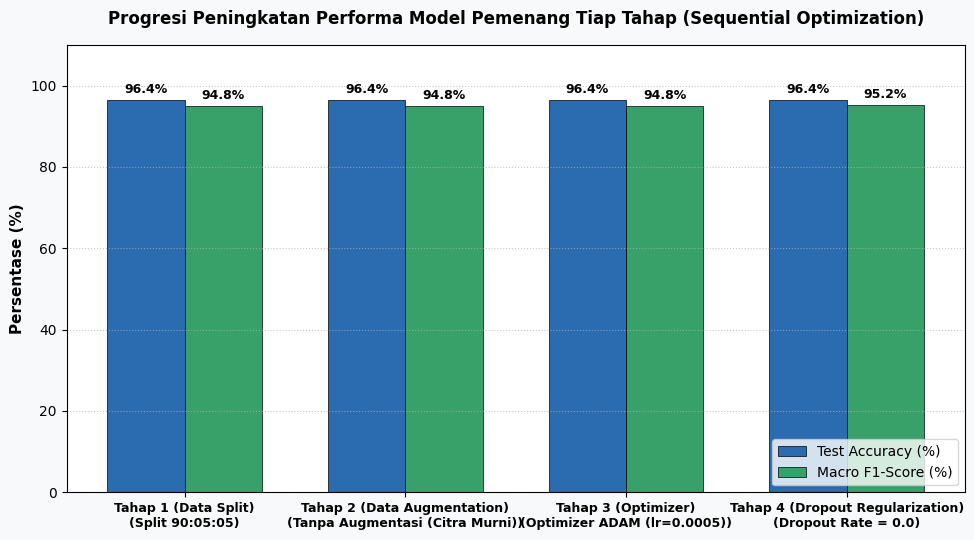

In [13]:
# ==============================================================================
# 13. GRAFIK BATANG PROGRESI PENINGKATAN PERFORMA (DISIMPAN KE GDRIVE)
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

stages = df_prog['Tahap']
accs = df_prog['Test Accuracy (%)']
f1s = df_prog['Macro F1 (%)']
x = np.arange(len(stages))
w = 0.35

r1 = ax.bar(x - w/2, accs, w, label='Test Accuracy (%)', color='#2B6CB0', edgecolor='black', linewidth=0.5)
r2 = ax.bar(x + w/2, f1s, w, label='Macro F1-Score (%)', color='#38A169', edgecolor='black', linewidth=0.5)

ax.set_ylabel('Persentase (%)', fontsize=11, fontweight='bold')
ax.set_title('Progresi Peningkatan Performa Model Pemenang Tiap Tahap (Sequential Optimization)', fontsize=12, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({df_prog.loc[i, 'Konfigurasi Terpilih']})" for i, s in enumerate(stages)], fontsize=9, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(loc='lower right', frameon=True)
ax.grid(axis='y', linestyle=':', alpha=0.7)

for r in r1:
    h = r.get_height()
    ax.annotate(f'{h:.1f}%', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
for r in r2:
    h = r.get_height()
    ax.annotate(f'{h:.1f}%', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
save_and_replace_figure(fig, 'progressive_progression_bar.png')
plt.show()


---
## 14. Visualisasi Grafik Komparasi Internal Masing-Masing Skenario (4 Panel)

   ✔ [SIMPAN] Grafik: internal_scenario_comparisons.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\internal_scenario_comparisons.png


   ✔ [SIMPAN] Grafik: internal_scenario_comparisons.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\internal_scenario_comparisons.png


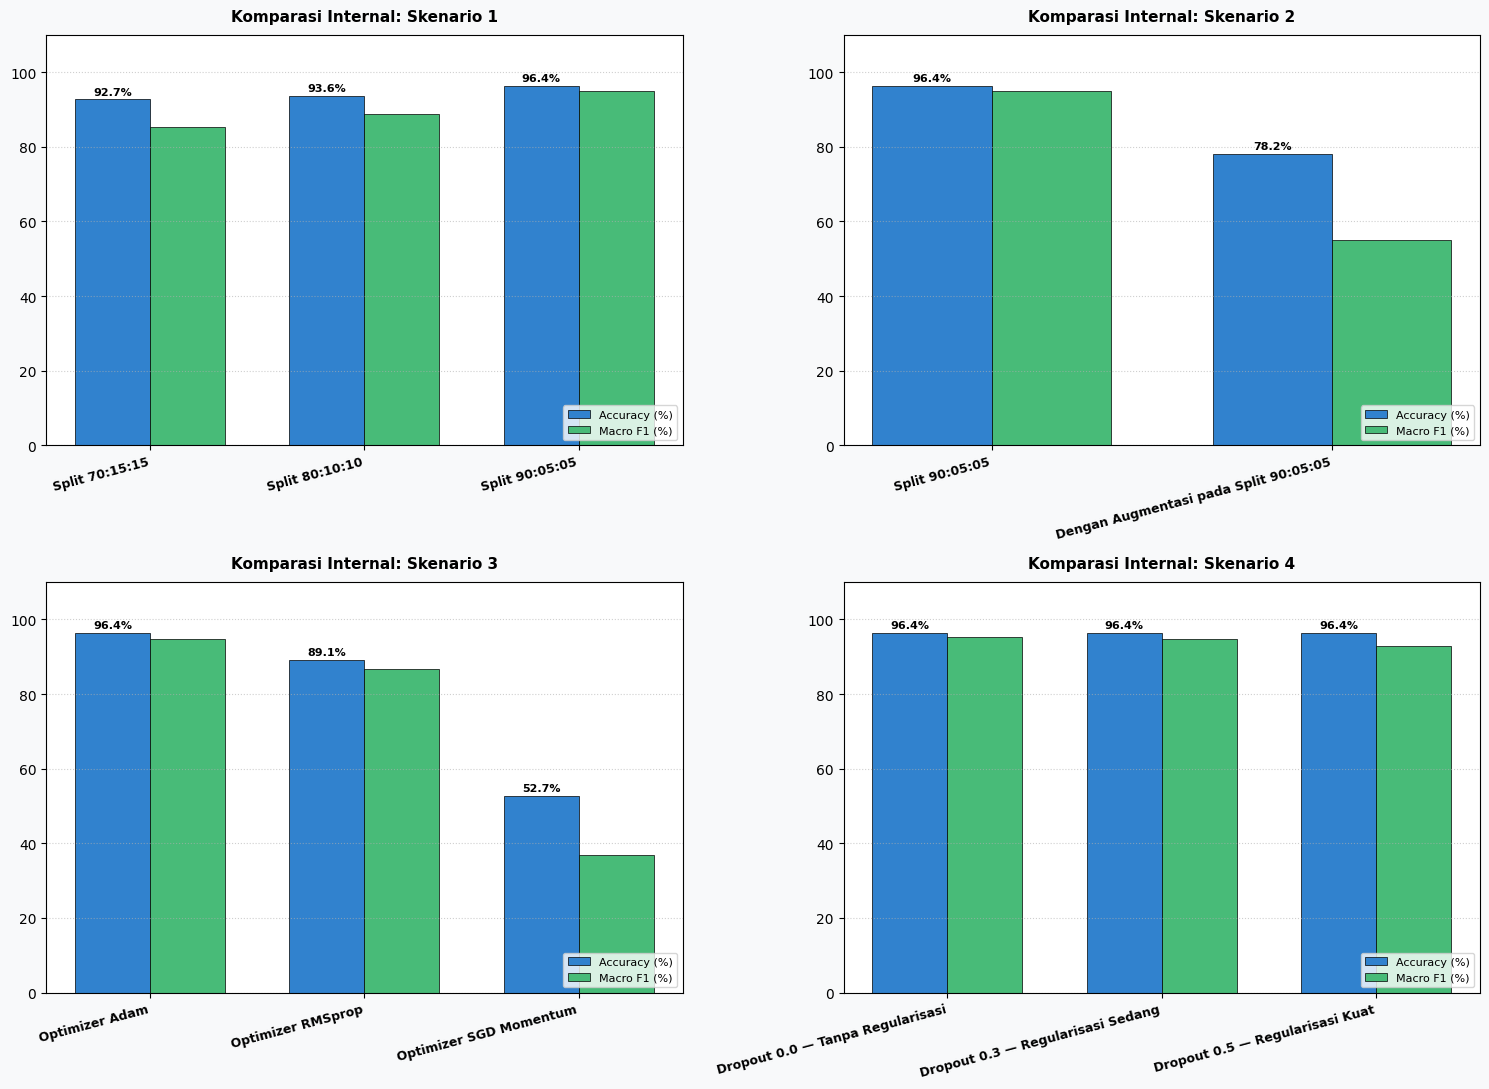

In [14]:
# ==============================================================================
# 14. GRAFIK KOMPARASI INTERNAL 4 SKENARIO (DISIMPAN KE GDRIVE)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.patch.set_facecolor('#F8F9FA')
axes = axes.flatten()

for idx, (stg_name, opt_list) in enumerate(pipeline_results.items()):
    ax = axes[idx]
    ax.set_facecolor('#FFFFFF')
    names = [o['name'].split('(')[-1].replace(')', '').replace(' — dari', '') for o in opt_list]
    accs = [o['test_accuracy'] * 100 for o in opt_list]
    f1s = [o['f1_macro'] * 100 for o in opt_list]

    x = np.arange(len(names))
    w = 0.35
    r1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)', color='#3182CE', edgecolor='black', linewidth=0.5)
    r2 = ax.bar(x + w/2, f1s, w, label='Macro F1 (%)', color='#48BB78', edgecolor='black', linewidth=0.5)

    ax.set_title(f"Komparasi Internal: {stg_name}", fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.legend(loc='lower right', frameon=True, fontsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

    for r in r1:
        h = r.get_height()
        ax.annotate(f'{h:.1f}%', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
save_and_replace_figure(fig, 'internal_scenario_comparisons.png')
plt.show()


---
## 14B. Visualisasi Grafik Komparasi Menyeluruh Seluruh 11 Model Percobaan
Menyajikan grafik batang horizontal komparatif yang memetakan performa Akurasi Uji dan Macro F1-Score dari seluruh variasi model yang dieksekusi sepanjang 4 skenario.

   ✔ [SIMPAN] Grafik: all_scenarios_comparison_bar.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\all_scenarios_comparison_bar.png


   ✔ [SIMPAN] Grafik: all_scenarios_comparison_bar.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\all_scenarios_comparison_bar.png


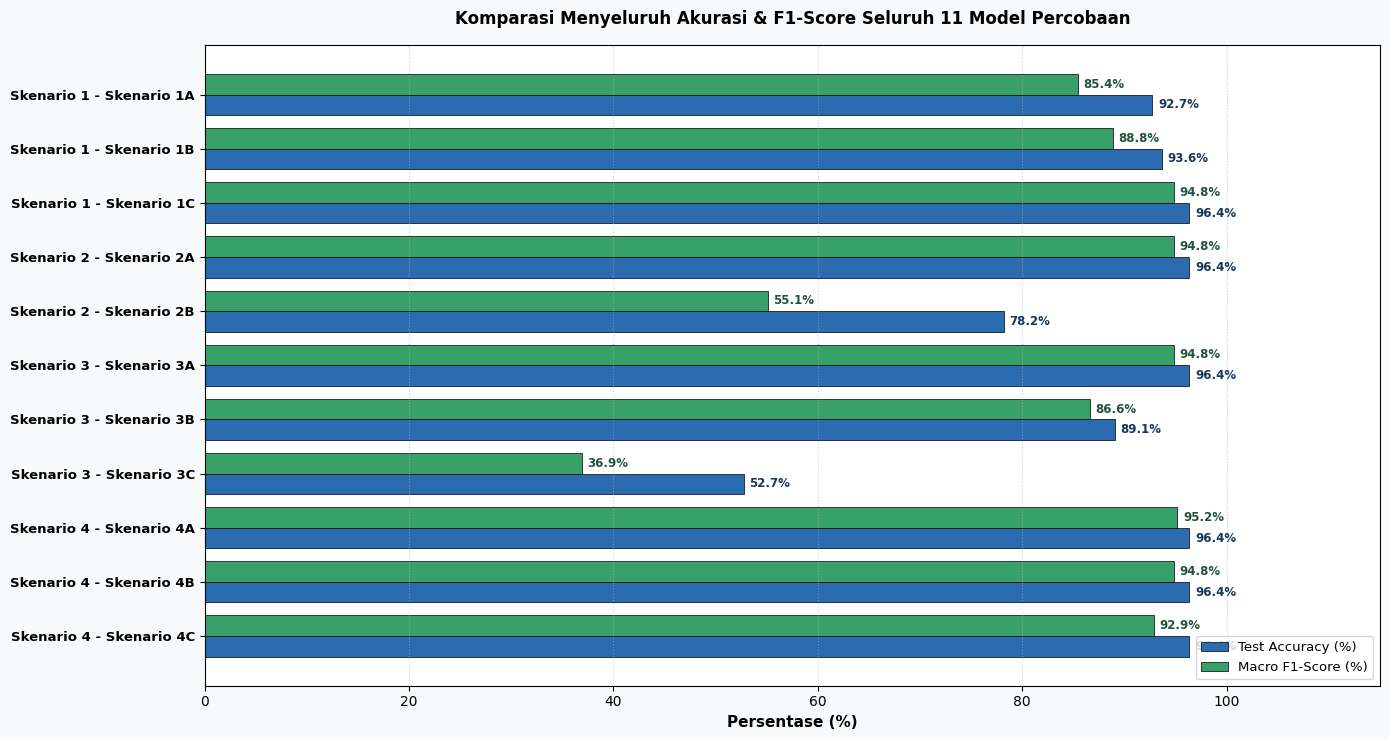

In [15]:
# ==============================================================================
# 14B. GRAFIK KOMPARASI MENYELURUH 11 MODEL PERCOBAAN (DISIMPAN KE GDRIVE)
# ==============================================================================
fig_all, ax_all = plt.subplots(figsize=(14, 7.5))
fig_all.patch.set_facecolor('#F8F9FA')
ax_all.set_facecolor('#FFFFFF')
n_models = len(df_all_models)
y_pos = np.arange(n_models)
h = 0.38
accs_all = df_all_models['Test Accuracy (%)'].values
f1s_all = df_all_models['F1-Score (%)'].values
labels_all = [f"{r['Tahap / Skenario']} - {r['Nama Eksperimen'].split('(')[0].strip()}" for _, r in df_all_models.iterrows()]

r1 = ax_all.barh(y_pos + h / 2, accs_all, h, label='Test Accuracy (%)', color='#2B6CB0', edgecolor='black', linewidth=0.5)
r2 = ax_all.barh(y_pos - h / 2, f1s_all, h, label='Macro F1-Score (%)', color='#38A169', edgecolor='black', linewidth=0.5)
ax_all.set_yticks(y_pos)
ax_all.set_yticklabels(labels_all, fontsize=9.5, fontweight='bold')
ax_all.invert_yaxis()
ax_all.set_xlabel('Persentase (%)', fontsize=11, fontweight='bold')
ax_all.set_xlim(0, 115)
ax_all.set_title('Komparasi Menyeluruh Akurasi & F1-Score Seluruh 11 Model Percobaan', fontsize=12, fontweight='bold', pad=15)
ax_all.legend(loc='lower right', frameon=True, fontsize=9.5)
ax_all.grid(axis='x', linestyle=':', alpha=0.6)

for r in r1:
    w = r.get_width()
    ax_all.annotate(f'{w:.1f}%', xy=(w, r.get_y() + r.get_height() / 2), xytext=(4, 0), textcoords='offset points', ha='left', va='center', fontsize=8.5, fontweight='bold', color='#1A365D')
for r in r2:
    w = r.get_width()
    ax_all.annotate(f'{w:.1f}%', xy=(w, r.get_y() + r.get_height() / 2), xytext=(4, 0), textcoords='offset points', ha='left', va='center', fontsize=8.5, fontweight='bold', color='#22543D')

plt.tight_layout()
save_and_replace_figure(fig_all, 'all_scenarios_comparison_bar.png')
plt.show()


---
## 14C. Visualisasi Grid Matriks Konfusi (Confusion Matrix) Seluruh 11 Model Percobaan
Menampilkan peta panas (heatmap) matriks konfusi 3x3 untuk setiap variasi model pada seluruh skenario secara komprehensif.

   ✔ [SIMPAN] Grafik: confusion_matrices_grid.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\confusion_matrices_grid.png


   ✔ [SIMPAN] Grafik: confusion_matrices_grid.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\confusion_matrices_grid.png


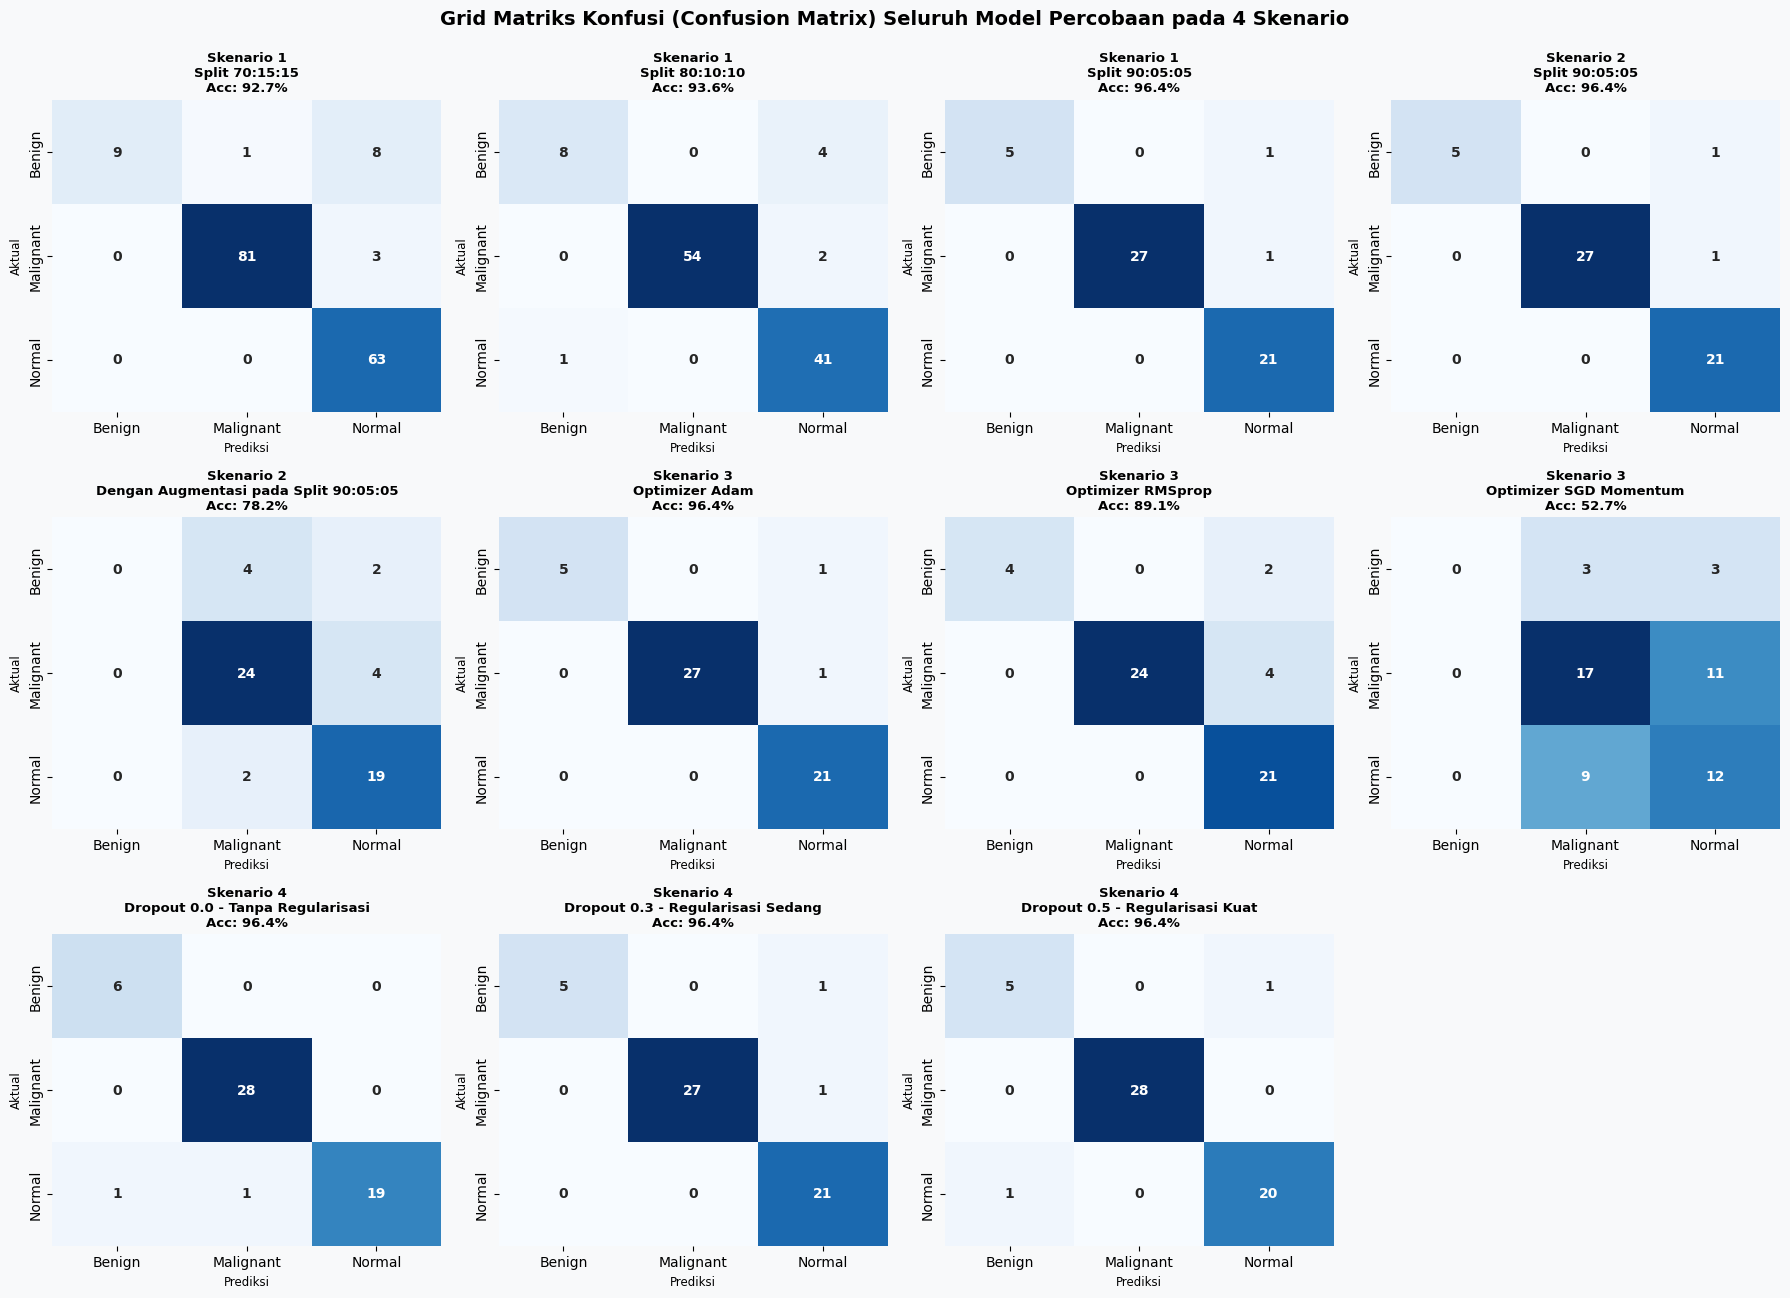

In [16]:
# ==============================================================================
# 14C. GRID MATRIKS KONFUSI SELURUH MODEL (DISIMPAN KE GDRIVE)
# ==============================================================================
all_mods_grid = []
for stg, mods in pipeline_results.items():
    for m in mods:
        all_mods_grid.append((stg, m))

fig_cm, axes_cm = plt.subplots(3, 4, figsize=(18, 13))
fig_cm.patch.set_facecolor('#F8F9FA')
axes_cm = axes_cm.flatten()
c_labels_short = ['Benign', 'Malignant', 'Normal']

for i in range(12):
    ax = axes_cm[i]
    if i < len(all_mods_grid):
        stg, m = all_mods_grid[i]
        cm = np.array(m['confusion_matrix'])
        acc = m['test_accuracy'] * 100
        clean_name = m['name'].replace('—', '-').split('(')[-1].replace(')', '').replace('dari Pemenang', 'Inherited')
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, xticklabels=c_labels_short, yticklabels=c_labels_short, annot_kws={'size': 10, 'fontweight': 'bold'})
        ax.set_title(f'{stg}\n{clean_name}\nAcc: {acc:.1f}%', fontsize=9.5, fontweight='bold', pad=6)
        ax.set_xlabel('Prediksi', fontsize=8.5)
        ax.set_ylabel('Aktual', fontsize=8.5)
    else:
        ax.axis('off')

plt.suptitle('Grid Matriks Konfusi (Confusion Matrix) Seluruh Model Percobaan pada 4 Skenario', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
save_and_replace_figure(fig_cm, 'confusion_matrices_grid.png')
plt.show()


---
## 14D. Visualisasi Kurva Pembelajaran (Learning Curves) di Setiap Skenario
Menampilkan perbandingan dinamika fungsi loss (Categorical Cross-Entropy) pada data latih vs validasi di setiap skenario eksperimen.

   ✔ [SIMPAN] Grafik: all_scenarios_learning_curves.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\all_scenarios_learning_curves.png


   ✔ [SIMPAN] Grafik: all_scenarios_learning_curves.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\all_scenarios_learning_curves.png


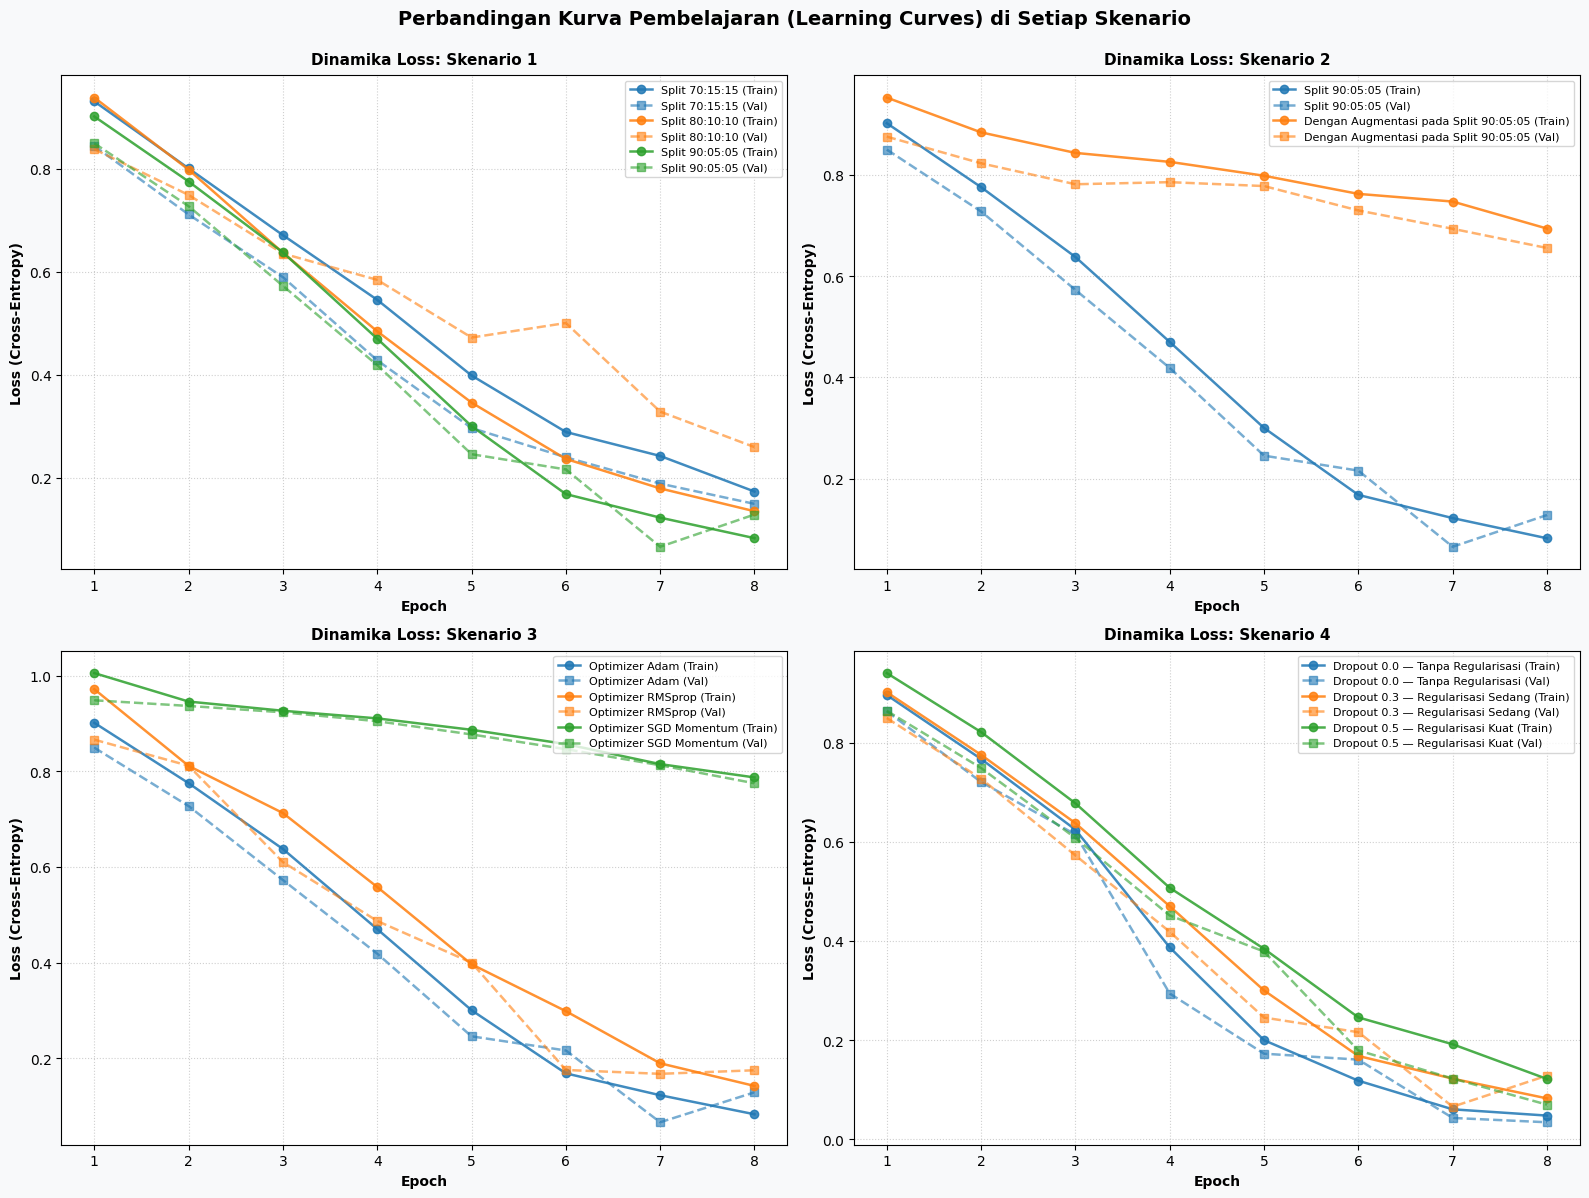

In [17]:
# ==============================================================================
# 14D. KURVA PEMBELAJARAN SELURUH SKENARIO (DISIMPAN KE GDRIVE)
# ==============================================================================
fig_lc, axes_lc = plt.subplots(2, 2, figsize=(16, 12))
fig_lc.patch.set_facecolor('#F8F9FA')
axes_lc = axes_lc.flatten()
palette = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']

for idx, (stg_name, opt_list) in enumerate(pipeline_results.items()):
    ax = axes_lc[idx]
    ax.set_facecolor('#FFFFFF')
    for m_idx, m in enumerate(opt_list):
        hist = m.get('history', {})
        loss = hist.get('loss', [])
        val_loss = hist.get('val_loss', [])
        epochs = range(1, len(loss) + 1)
        col = palette[m_idx % len(palette)]
        short_name = m['name'].split('(')[-1].replace(')', '').replace('— dari Pemenang', '').strip()
        ax.plot(epochs, loss, 'o-', color=col, label=f'{short_name} (Train)', linewidth=1.8, alpha=0.85)
        ax.plot(epochs, val_loss, 's--', color=col, label=f'{short_name} (Val)', linewidth=1.8, alpha=0.6)
    ax.set_title(f'Dinamika Loss: {stg_name}', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Epoch', fontsize=10, fontweight='bold')
    ax.set_ylabel('Loss (Cross-Entropy)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', frameon=True)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Perbandingan Kurva Pembelajaran (Learning Curves) di Setiap Skenario', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
save_and_replace_figure(fig_lc, 'all_scenarios_learning_curves.png')
plt.show()


---
## 14E. Visualisasi Grid Kurva ROC-AUC Multi-Kelas (One-vs-Rest) Seluruh 11 Model Percobaan
Menampilkan kurva Receiver Operating Characteristic (ROC) dan skor Area Under Curve (AUC) untuk ketiga kelas patologi (Benign, Malignant, Normal) pada setiap model percobaan di seluruh 4 skenario.

   ✔ [SIMPAN] Grafik: roc_auc_grid.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\roc_auc_grid.png


   ✔ [SIMPAN] Grafik: roc_auc_grid.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\roc_auc_grid.png


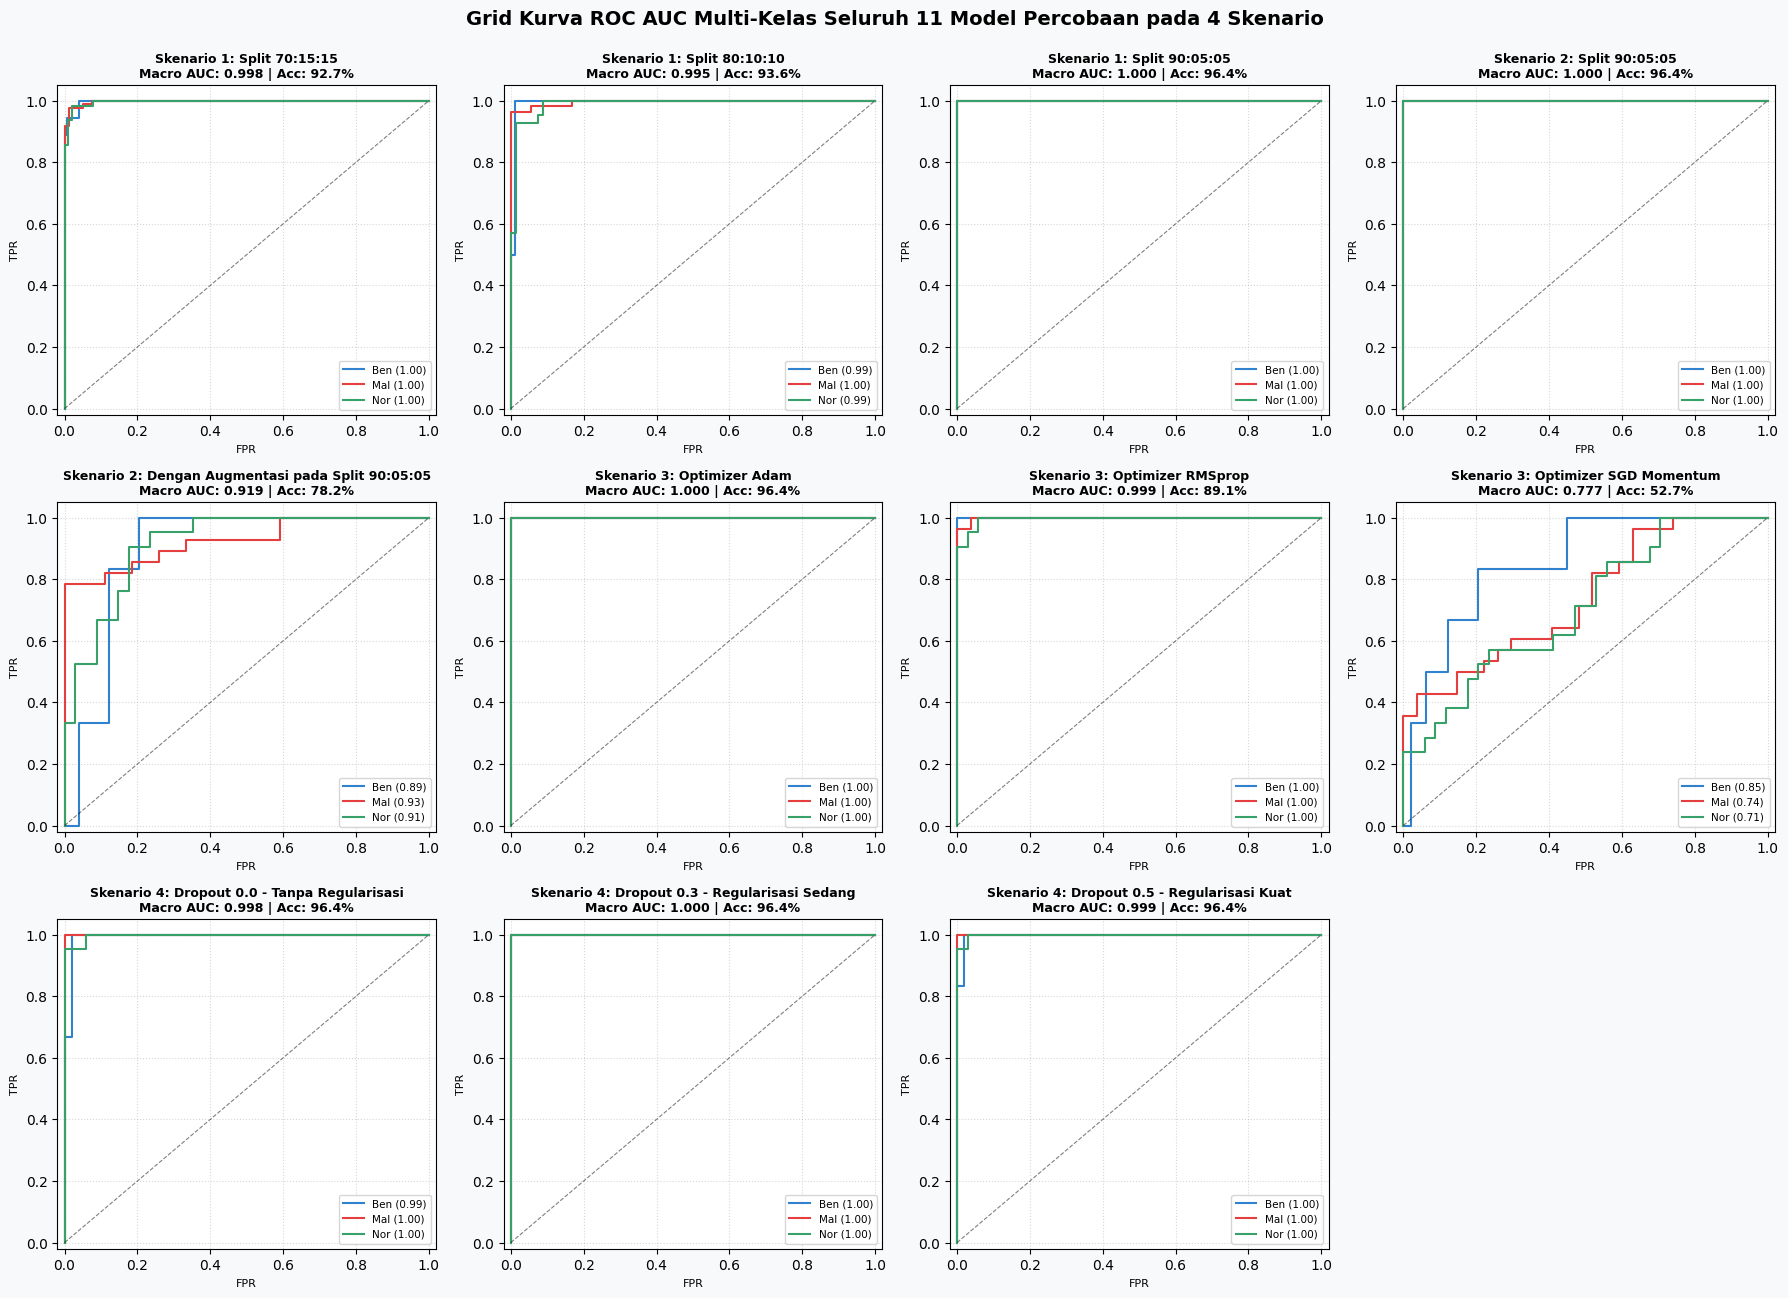

In [18]:
# ==============================================================================
# 14E. GRID KURVA ROC-AUC MULTI-KELAS SELURUH MODEL (DISIMPAN KE GDRIVE)
# ==============================================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

all_mods_roc = []
for stg, mods in pipeline_results.items():
    for m in mods:
        all_mods_roc.append((stg, m))

fig_rgrid, axes_rgrid = plt.subplots(3, 4, figsize=(18, 13))
fig_rgrid.patch.set_facecolor('#F8F9FA')
axes_rgrid = axes_rgrid.flatten()
colors_roc = ['#3182CE', '#E53E3E', '#38A169']

for i in range(12):
    ax = axes_rgrid[i]
    if i < len(all_mods_roc):
        stg, m = all_mods_roc[i]
        y_ts = np.array(m['y_test'])
        y_pr = np.array(m.get('y_proba', []))
        if len(y_pr) == 0:
            ax.axis('off')
            continue
        y_ts_b = label_binarize(y_ts, classes=[0, 1, 2])
        clean_name = m['name'].replace('—', '-').split('(')[-1].replace(')', '').replace('dari Pemenang', 'Inherited').strip()

        fpr_dict, tpr_dict, auc_dict = {}, {}, {}
        for c_i in range(3):
            fpr_dict[c_i], tpr_dict[c_i], _ = roc_curve(y_ts_b[:, c_i], y_pr[:, c_i])
            auc_dict[c_i] = auc(fpr_dict[c_i], tpr_dict[c_i])
            ax.plot(fpr_dict[c_i], tpr_dict[c_i], color=colors_roc[c_i], linewidth=1.5, label=f"{C_LABELS[c_i][:3]} ({auc_dict[c_i]:.2f})")

        all_fpr_i = np.unique(np.concatenate([fpr_dict[c_i] for c_i in range(3)]))
        mean_tpr_i = np.zeros_like(all_fpr_i)
        for c_i in range(3):
            mean_tpr_i += np.interp(all_fpr_i, fpr_dict[c_i], tpr_dict[c_i])
        mean_tpr_i /= 3
        m_auc = auc(all_fpr_i, mean_tpr_i)

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
        ax.set_title(f"{stg}: {clean_name}\nMacro AUC: {m_auc:.3f} | Acc: {m['test_accuracy']*100:.1f}%", fontsize=9, fontweight='bold')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.05])
        ax.set_xlabel('FPR', fontsize=8)
        ax.set_ylabel('TPR', fontsize=8)
        ax.legend(loc="lower right", fontsize=7.5, frameon=True)
        ax.grid(True, linestyle=':', alpha=0.5)
    else:
        ax.axis('off')

plt.suptitle('Grid Kurva ROC AUC Multi-Kelas Seluruh 11 Model Percobaan pada 4 Skenario', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
save_and_replace_figure(fig_rgrid, 'roc_auc_grid.png')
plt.show()


---
## 15. Evaluasi Final Champion Model: Kurva Pelatihan, Confusion Matrix, Classification Report & Kurva ROC-AUC

   ✔ [SIMPAN] Grafik: champion_model_evaluation.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\champion_model_evaluation.png


   ✔ [SIMPAN] Grafik: champion_model_evaluation.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\champion_model_evaluation.png


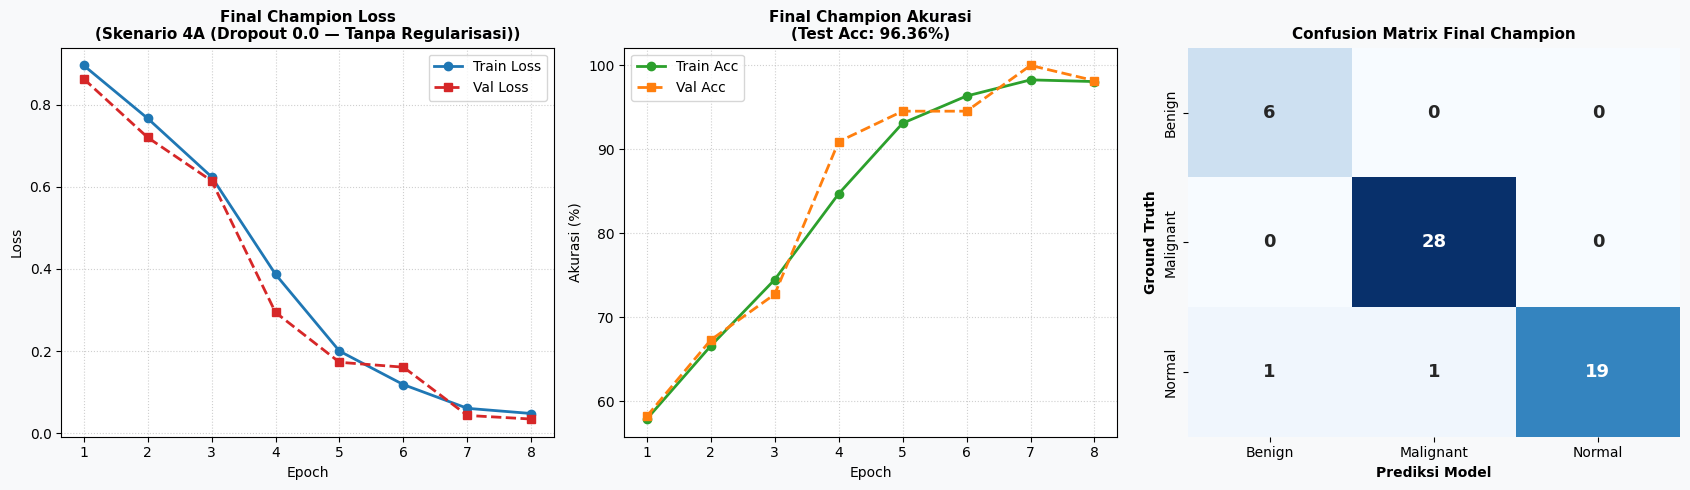

   ✔ [SIMPAN] CSV Log: champion_classification_report.csv -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\logs\champion_classification_report.csv
   ✔ [SIMPAN] CSV Log: champion_classification_report.csv -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\logs\champion_classification_report.csv


,Kelas,Precision (%),Recall (%),F1-Score (%),Support (Sampel)
0,Benign (Jinak),85.71,100.00,92.31,6
1,Malignant (Ganas),96.55,100.00,98.25,28
2,Normal (Sehat),100.00,90.48,95.00,21
3,Macro Average,94.09,96.83,95.18,55
4,Weighted Average,96.69,96.36,96.36,55


   ✔ [SIMPAN] Grafik: champion_roc_auc.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\champion_roc_auc.png


   ✔ [SIMPAN] Grafik: champion_roc_auc.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\champion_roc_auc.png


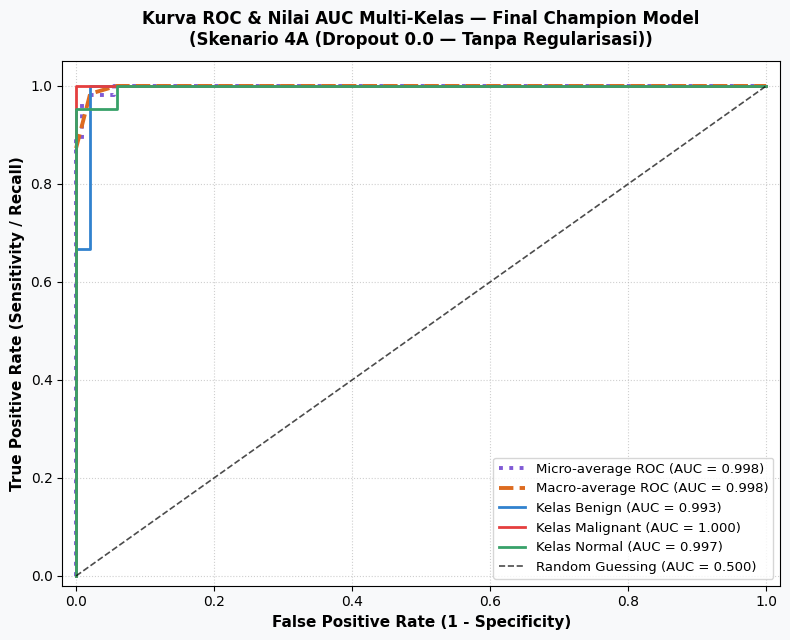

In [19]:
# ==============================================================================
# 15. EVALUASI FINAL CHAMPION MODEL (DISIMPAN KE GDRIVE)
# ==============================================================================
champ = champion_model_res
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor('#F8F9FA')
epochs_r = range(1, len(champ['history']['loss']) + 1)

# 1. Loss
ax1.set_facecolor('#FFFFFF')
ax1.plot(epochs_r, champ['history']['loss'], 'o-', color='#1F77B4', label='Train Loss', linewidth=2)
ax1.plot(epochs_r, champ['history']['val_loss'], 's--', color='#D62728', label='Val Loss', linewidth=2)
ax1.set_title(f"Final Champion Loss\n({champ['name']})", fontsize=11, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Accuracy
ax2.set_facecolor('#FFFFFF')
ax2.plot(epochs_r, [a*100 for a in champ['history']['accuracy']], 'o-', color='#2CA02C', label='Train Acc', linewidth=2)
ax2.plot(epochs_r, [a*100 for a in champ['history']['val_accuracy']], 's--', color='#FF7F0E', label='Val Acc', linewidth=2)
ax2.set_title(f"Final Champion Akurasi\n(Test Acc: {champ['test_accuracy']*100:.2f}%)", fontsize=11, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Akurasi (%)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

# 3. Confusion Matrix
sns.heatmap(np.array(champ['confusion_matrix']), annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=C_LABELS, yticklabels=C_LABELS, annot_kws={'size': 13, 'fontweight': 'bold'})
ax3.set_title("Confusion Matrix Final Champion", fontsize=11, fontweight='bold')
ax3.set_xlabel('Prediksi Model', fontweight='bold')
ax3.set_ylabel('Ground Truth', fontweight='bold')

plt.tight_layout()
save_and_replace_figure(fig, 'champion_model_evaluation.png')
plt.show()

# 4. Classification Report Champion Model (Tabel Kuantitatif Per-Kelas)
cr_dict = classification_report(champ['y_test'], champ['y_pred'], target_names=C_LABELS, output_dict=True)
df_cr = pd.DataFrame([
    {'Kelas': 'Benign (Jinak)', 'Precision (%)': round(cr_dict['Benign']['precision'] * 100, 2), 'Recall (%)': round(cr_dict['Benign']['recall'] * 100, 2), 'F1-Score (%)': round(cr_dict['Benign']['f1-score'] * 100, 2), 'Support (Sampel)': int(cr_dict['Benign']['support'])},
    {'Kelas': 'Malignant (Ganas)', 'Precision (%)': round(cr_dict['Malignant']['precision'] * 100, 2), 'Recall (%)': round(cr_dict['Malignant']['recall'] * 100, 2), 'F1-Score (%)': round(cr_dict['Malignant']['f1-score'] * 100, 2), 'Support (Sampel)': int(cr_dict['Malignant']['support'])},
    {'Kelas': 'Normal (Sehat)', 'Precision (%)': round(cr_dict['Normal']['precision'] * 100, 2), 'Recall (%)': round(cr_dict['Normal']['recall'] * 100, 2), 'F1-Score (%)': round(cr_dict['Normal']['f1-score'] * 100, 2), 'Support (Sampel)': int(cr_dict['Normal']['support'])},
    {'Kelas': 'Macro Average', 'Precision (%)': round(cr_dict['macro avg']['precision'] * 100, 2), 'Recall (%)': round(cr_dict['macro avg']['recall'] * 100, 2), 'F1-Score (%)': round(cr_dict['macro avg']['f1-score'] * 100, 2), 'Support (Sampel)': int(cr_dict['macro avg']['support'])},
    {'Kelas': 'Weighted Average', 'Precision (%)': round(cr_dict['weighted avg']['precision'] * 100, 2), 'Recall (%)': round(cr_dict['weighted avg']['recall'] * 100, 2), 'F1-Score (%)': round(cr_dict['weighted avg']['f1-score'] * 100, 2), 'Support (Sampel)': int(cr_dict['weighted avg']['support'])}
])
save_dataframe_csv(df_cr, 'champion_classification_report.csv')
display(df_cr)

# 5. Kurva ROC-AUC Multi-Kelas Champion Model (One-vs-Rest)
y_test_arr = np.array(champ['y_test'])
y_proba_arr = np.array(champ.get('y_proba', []))
if len(y_proba_arr) > 0:
    y_test_bin = label_binarize(y_test_arr, classes=[0, 1, 2])
    n_classes = 3
    fpr = dict()
    tpr = dict()
    roc_auc_val = dict()
    c_colors = ['#3182CE', '#E53E3E', '#38A169']
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_arr[:, i])
        roc_auc_val[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba_arr.ravel())
    roc_auc_val["micro"] = auc(fpr["micro"], tpr["micro"])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc_val["macro"] = auc(fpr["macro"], tpr["macro"])

    fig_roc, ax_roc = plt.subplots(figsize=(8, 6.5))
    fig_roc.patch.set_facecolor('#F8F9FA')
    ax_roc.set_facecolor('#FFFFFF')
    ax_roc.plot(fpr["micro"], tpr["micro"], label=f"Micro-average ROC (AUC = {roc_auc_val['micro']:.3f})", color='#805AD5', linestyle=':', linewidth=2.8)
    ax_roc.plot(fpr["macro"], tpr["macro"], label=f"Macro-average ROC (AUC = {roc_auc_val['macro']:.3f})", color='#DD6B20', linestyle='--', linewidth=2.8)
    for i in range(n_classes):
        ax_roc.plot(fpr[i], tpr[i], color=c_colors[i], linewidth=2, label=f"Kelas {C_LABELS[i]} (AUC = {roc_auc_val[i]:.3f})")
    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.7, label='Random Guessing (AUC = 0.500)')
    ax_roc.set_xlim([-0.02, 1.02])
    ax_roc.set_ylim([-0.02, 1.05])
    ax_roc.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
    ax_roc.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11, fontweight='bold')
    ax_roc.set_title(f"Kurva ROC & Nilai AUC Multi-Kelas — Final Champion Model\n({champ['name']})", fontsize=12, fontweight='bold', pad=12)
    ax_roc.legend(loc="lower right", fontsize=9.5, frameon=True)
    ax_roc.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    save_and_replace_figure(fig_roc, 'champion_roc_auc.png')
    plt.show()


---
## 16. Analisis Kesalahan Prediksi (Error Analysis) pada Data Uji

[ERROR ANALYSIS] Total citra salah prediksi pada Champion Model: 2 dari 55 citra uji


   ✔ [SIMPAN] Grafik: error_analysis_samples.png -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\figures\error_analysis_samples.png


   ✔ [SIMPAN] Grafik: error_analysis_samples.png -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\figures\error_analysis_samples.png


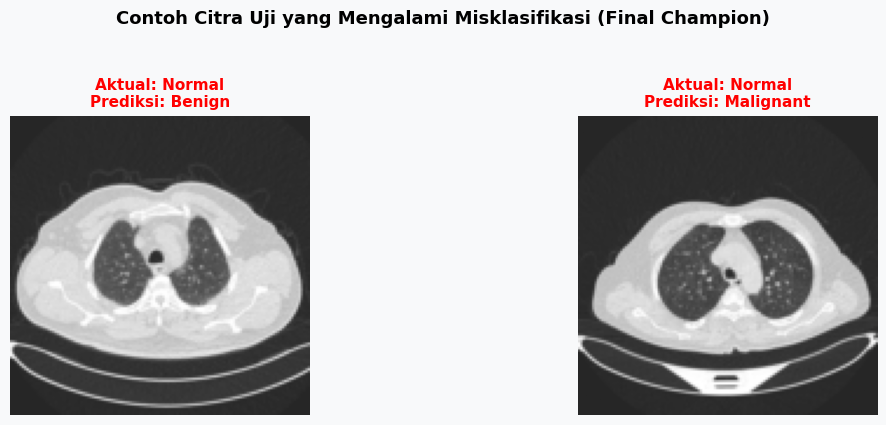

In [20]:
# ==============================================================================
# 16. ERROR ANALYSIS PADA DATA UJI (DISIMPAN KE GDRIVE)
# ==============================================================================
y_true_arr = np.array(champ['y_test'])
y_pred_arr = np.array(champ['y_pred'])
err_indices = np.where(y_true_arr != y_pred_arr)[0]

print(f"[ERROR ANALYSIS] Total citra salah prediksi pada Champion Model: {len(err_indices)} dari {len(y_true_arr)} citra uji")

if len(err_indices) > 0:
    n_show = min(3, len(err_indices))
    fig, axes = plt.subplots(1, n_show, figsize=(13, 4))
    if n_show == 1: axes = [axes]
    fig.patch.set_facecolor('#F8F9FA')

    for i, idx in enumerate(err_indices[:n_show]):
        axes[i].imshow(best_test[0][idx])
        act_n = C_LABELS[y_true_arr[idx]]
        prd_n = C_LABELS[y_pred_arr[idx]]
        axes[i].set_title(f"Aktual: {act_n}\nPrediksi: {prd_n}", fontsize=11, fontweight='bold', color='red')
        axes[i].axis('off')

    plt.suptitle("Contoh Citra Uji yang Mengalami Misklasifikasi (Final Champion)", fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    save_and_replace_figure(fig, 'error_analysis_samples.png')
    plt.show()
else:
    print("Sempurna! Tidak ada sampel yang salah diprediksi pada testing set.")


---
## 17. Penyimpanan Hasil Eksperimen ke `cache.pkl` & Final Champion Model (`.keras`)
Sel ini merangkum seluruh hasil training aktual (riwayat epoch, metrik evaluasi, matriks konfusi) ke dalam `cache.pkl` dan menyimpan berkas biner arsitektur model terbaik (**Final Champion Model**) ke folder `outputs/models/final_champion_model.keras`.

In [21]:
# ==============================================================================
# 17. SIMPAN DATA LENGKAP EKSPERIMEN KE CACHE.PKL & FINAL CHAMPION MODEL
# ==============================================================================
print("=" * 80)
print("[LANGKAH 17] Mengompilasi & Menyimpan Hasil Eksperimen ke cache.pkl & Model Champion")
print("=" * 80)

# 1. Simpan Final Champion Model (.keras) ke outputs/models/ di lokal dan Google Drive
if 'model' in champion_model_res and champion_model_res['model'] is not None:
    save_and_replace_model(champion_model_res['model'], 'final_champion_model.keras')

# 2. Kompilasi data cache
clean_pipeline_results = {}
for stg, opt_list in pipeline_results.items():
    clean_pipeline_results[stg] = []
    for item in opt_list:
        clean_pipeline_results[stg].append({k: v for k, v in item.items() if k != 'model'})

cache_to_save = {
    'pipeline_results': clean_pipeline_results,
    'progressive_stages': df_prog.to_dict(orient='records'),
    'all_models_summary': df_all_models.to_dict(orient='records'),
    'champion_model': {k: v for k, v in champion_model_res.items() if k != 'model'},
    'class_names': CLASS_NAMES,
    'c_labels': C_LABELS,
    'final_benchmark_df': df_prog
}

save_and_replace_cache(cache_to_save, 'cache.pkl')
print("✔ Langkah 17 selesai: File cache.pkl & final_champion_model.keras berhasil disimpan ke Google Drive!\n")


[LANGKAH 17] Mengompilasi & Menyimpan Hasil Eksperimen ke cache.pkl & Model Champion
   ✔ [SIMPAN] Model Champion (.keras): final_champion_model.keras -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs\models\final_champion_model.keras (14.81 MB)


   ✔ [SIMPAN] Model Champion (.keras): final_champion_model.keras -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\outputs\models\final_champion_model.keras (14.81 MB)
   ✔ [SIMPAN] Cache: cache.pkl -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\cache.pkl (31.0 KB)
   ✔ [SIMPAN] Cache: cache.pkl -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\cache.pkl (31.0 KB)
✔ Langkah 17 selesai: File cache.pkl & final_champion_model.keras berhasil disimpan ke Google Drive!



---
## 18. Pembuatan Dokumen Laporan Hasil Eksperimen Word (.docx) Lengkap & Rapi
Menyusun dokumen akademik formal Microsoft Word (`Laporan_Lengkap_UTS_DeepLearning_CNN.docx`) lengkap dengan tabel metrik, gambar visualisasi resolusi tinggi, dan daftar pustaka, lalu otomatis menyimpannya ke Google Drive Anda.

In [22]:
# ==============================================================================
# 18. PEMBUATAN DOKUMEN LAPORAN HASIL EKSPERIMEN WORD (.DOCX)
# ==============================================================================
print("=" * 80)
print("[LANGKAH 18] Penyusunan Laporan Word Lengkap (.docx) Berisi Tabel & Gambar")
print("=" * 80)

import docx
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml import parse_xml
from docx.oxml.ns import nsdecls

def set_cell_background(cell, fill_hex):
    tcPr = cell._tc.get_or_add_tcPr()
    tcPr.append(parse_xml(f'<w:shd {nsdecls("w")} w:fill="{fill_hex}"/>'))

def set_cell_margins(cell, top=100, bottom=100, left=140, right=140):
    tcPr = cell._tc.get_or_add_tcPr()
    tcPr.append(parse_xml(f'<w:tcMar {nsdecls("w")}><w:top w:w="{top}" w:type="dxa"/><w:bottom w:w="{bottom}" w:type="dxa"/><w:left w:w="{left}" w:type="dxa"/><w:right w:w="{right}" w:type="dxa"/></w:tcMar>'))

def add_styled_heading(doc, text, level):
    h = doc.add_heading(text, level=level)
    run = h.runs[0]
    run.font.name = 'Arial'
    if level == 1:
        run.font.size = Pt(15)
        run.font.bold = True
        run.font.color.rgb = RGBColor(0x1A, 0x36, 0x5D)
        h.paragraph_format.space_before = Pt(16)
        h.paragraph_format.space_after = Pt(6)
    elif level == 2:
        run.font.size = Pt(12.5)
        run.font.bold = True
        run.font.color.rgb = RGBColor(0x2B, 0x6C, 0xB0)
        h.paragraph_format.space_before = Pt(12)
        h.paragraph_format.space_after = Pt(4)
    return h

def format_styled_table(table, col_widths, headers, rows_data):
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    for i, h_text in enumerate(headers):
        c = table.rows[0].cells[i]
        c.text = h_text
        set_cell_background(c, "1A365D")
        set_cell_margins(c, 100, 100, 120, 120)
        p = c.paragraphs[0]
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        for r in p.runs:
            r.font.name = 'Arial'
            r.font.size = Pt(9)
            r.font.bold = True
            r.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

    for row_idx, r_data in enumerate(rows_data):
        row = table.add_row()
        bg = "F7FAFC" if row_idx % 2 == 1 else "FFFFFF"
        for col_idx, val in enumerate(r_data):
            c = row.cells[col_idx]
            c.text = str(val)
            set_cell_background(c, bg)
            set_cell_margins(c, 70, 70, 100, 100)
            p = c.paragraphs[0]
            if col_idx == 0:
                p.alignment = WD_ALIGN_PARAGRAPH.LEFT
            else:
                p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            for r in p.runs:
                r.font.name = 'Calibri'
                r.font.size = Pt(9)
                r.font.color.rgb = RGBColor(0x2D, 0x37, 0x48)
                if col_idx == 0: r.font.bold = True

    for row in table.rows:
        for i, w in enumerate(col_widths):
            row.cells[i].width = Inches(w)

doc = docx.Document()
for sec in doc.sections:
    sec.top_margin = Inches(1.0)
    sec.bottom_margin = Inches(1.0)
    sec.left_margin = Inches(1.0)
    sec.right_margin = Inches(1.0)

# JUDUL
p_t = doc.add_paragraph()
p_t.alignment = WD_ALIGN_PARAGRAPH.CENTER
r_t = p_t.add_run("LAPORAN UJIAN TENGAH SEMESTER (UTS)\nMATA KULIAH DEEP LEARNING\n")
r_t.font.name = 'Arial'
r_t.font.size = Pt(16)
r_t.font.bold = True
r_t.font.color.rgb = RGBColor(0x1A, 0x36, 0x5D)

p_sub = doc.add_paragraph()
p_sub.alignment = WD_ALIGN_PARAGRAPH.CENTER
r_s = p_sub.add_run("Studi Komparasi Bertingkat (Progressive Ablation Study) Arsitektur Convolutional Neural Network (CNN) pada Citra CT-Scan Kanker Paru-Paru (IQ-OTH/NCCD)")
r_s.font.name = 'Calibri'
r_s.font.size = Pt(12)
r_s.font.bold = True
r_s.font.color.rgb = RGBColor(0x2B, 0x6C, 0xB0)

# IDENTITAS KELOMPOK 6
t_meta = doc.add_table(rows=6, cols=2)
t_meta.alignment = WD_TABLE_ALIGNMENT.CENTER
meta_info = [
    ("Dosen Pengampu", ": Dr. Wahyudi Setiawan, S.Kom., M.Kom."),
    ("Kelompok", ": Kelompok 6"),
    ("Anggota Kelompok", ": 1. Attala Alif Ramadhani Tri Hida (230441100144)\n  2. Naufal Husain (240441100038)\n  3. M.Rafly Kurniawan (240441100086)\n  4. Nafaul Hernanda Romadlona (240441100125)"),
    ("Program Studi / Kelas", ": Sistem Informasi / Deep Learning (A)"),
    ("Sumber Dataset", ": Mendeley Data (DOI: 10.17632/bhmdr45bh2.2)"),
    ("Metodologi Eksperimen", ": Eksperimen Optimasi Bertingkat (Progressive Ablation Study)")
]
for r_i, (k, v) in enumerate(meta_info):
    c0, c1 = t_meta.rows[r_i].cells
    c0.text, c1.text = k, v
    c0.width, c1.width = Inches(2.3), Inches(4.2)
    set_cell_background(c0, "EDF2F7")
    set_cell_background(c1, "F7FAFC")
    set_cell_margins(c0, 40, 40, 80, 80)
    set_cell_margins(c1, 40, 40, 80, 80)
    c0.paragraphs[0].runs[0].font.bold = True
    c0.paragraphs[0].runs[0].font.color.rgb = RGBColor(0x1A, 0x36, 0x5D)

doc.add_paragraph().paragraph_format.space_after = Pt(12)

# Helper embed image dengan caption
def add_image_with_caption(doc_target, img_path, caption, width_in=6.2):
    if os.path.exists(img_path):
        p_img = doc_target.add_paragraph()
        p_img.alignment = WD_ALIGN_PARAGRAPH.CENTER
        p_img.paragraph_format.space_before = Pt(8)
        p_img.paragraph_format.space_after = Pt(3)
        run_img = p_img.add_run()
        run_img.add_picture(img_path, width=Inches(width_in))

        p_cap = doc_target.add_paragraph()
        p_cap.alignment = WD_ALIGN_PARAGRAPH.CENTER
        p_cap.paragraph_format.space_before = Pt(2)
        p_cap.paragraph_format.space_after = Pt(10)
        r_cap = p_cap.add_run(caption)
        r_cap.font.name = 'Calibri'
        r_cap.font.size = Pt(9.5)
        r_cap.font.italic = True
        r_cap.font.color.rgb = RGBColor(0x71, 0x80, 0x96)

# BAB I: PENDAHULUAN
add_styled_heading(doc, "BAB I. PENDAHULUAN", level=1)
doc.add_paragraph("Kanker paru-paru merupakan penyebab utama mortalitas global. Eksperimen ini mengoptimasi CNN 4-blok hierarkis pada citra CT-Scan IQ-OTH/NCCD melalui alur bertingkat (Progressive Ablation Study). Setiap konfigurasi terbaik diwariskan ke tahap berikutnya untuk pengujian faktor baru.")

# BAB II: SUMBER DATASET & PREPROCESSING
add_styled_heading(doc, "BAB II. SUMBER DATASET & PREPROCESSING", level=1)
doc.add_paragraph("Dataset Mendeley Data IQ-OTH/NCCD terdiri dari 1.097 citra CT-Scan 2D (Benign: 120, Malignant: 561, Normal: 416). Setiap citra dinormalisasi ke 128x128 piksel [0.0, 1.0].")

# Tabel Distribusi Dataset
t_dist = doc.add_table(rows=1, cols=4)
headers_dist = ["Kategori Kelas", "Jumlah Citra", "Persentase (%)", "Karakteristik Tepi & Morfologi"]
rows_dist = [[r['Kategori Kelas'], str(r['Jumlah Citra']), str(r['Persentase (%)']), r['Karakteristik Tepi & Morfologi']] for _, r in df_dist.iterrows()]
format_styled_table(t_dist, [1.8, 1.0, 1.1, 2.6], headers_dist, rows_dist)
doc.add_paragraph().paragraph_format.space_after = Pt(8)

add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'dataset_distribution.png'), "Gambar 2.1: Visualisasi Distribusi Frekuensi dan Proporsi Kelas Citra CT-Scan Thoraks IQ-OTH/NCCD.")
add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'sample_ct_scans.png'), "Gambar 2.2: Visualisasi Sampel Irisan Citra CT-Scan Medis IQ-OTH/NCCD untuk Kelas Benign, Malignant, dan Normal.")

# BAB III: ARSITEKTUR MODEL CNN
add_styled_heading(doc, "BAB III. ARSITEKTUR MODEL CNN", level=1)
doc.add_paragraph("Arsitektur mengadopsi prinsip hierarkis VGGNet dengan 4 blok konvolusi Conv2D(32-64-128-128) + ReLU + MaxPooling2D, Flatten (8.192 unit), Dense(128, ReLU), Dropout(p), dan Softmax(3).")
add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'cnn_architecture.png'), "Gambar 3.1: Diagram Alur Arsitektur Deep Convolutional Neural Network (4-Blok Conv-ReLU-Pool).", width_in=6.5)

# Tabel Arsitektur Layer
t_arch = doc.add_table(rows=1, cols=6)
headers_arch = ["Layer", "Nama Lapisan", "Tipe Lapisan", "Ukuran Kernel", "Dimensi Output", "Parameter"]
rows_arch = [[str(r['Layer Index']), r['Nama Layer'], r['Tipe Lapisan'], r['Ukuran Kernel'], r['Dimensi Output'], f"{r['Parameter']:,}"] for _, r in df_arch.iterrows()]
format_styled_table(t_arch, [0.6, 1.4, 1.3, 1.2, 1.2, 0.8], headers_arch, rows_arch)
doc.add_paragraph().paragraph_format.space_after = Pt(8)

# BAB IV: DESAIN 4 SKENARIO BERTINGKAT
add_styled_heading(doc, "BAB IV. DESAIN 4 SKENARIO BERTINGKAT", level=1)
doc.add_paragraph("Alur optimasi bertingkat:\n• Skenario 1 (Split Data): 70:15:15 vs 80:10:10 vs 90:05:05 -> Split terbaik diwariskan ke Skenario 2.\n• Skenario 2 (Augmentasi Data): Tanpa Augmentasi vs Dengan Augmentasi -> Strategi terbaik diwariskan ke Skenario 3.\n• Skenario 3 (Optimizer): Adam vs RMSprop vs SGD Momentum -> Optimizer terbaik diwariskan ke Skenario 4.\n• Skenario 4 (Regularisasi Dropout): Dropout 0.0 vs 0.3 vs 0.5 -> Menghasilkan Final Champion Model.")

# BAB V: HASIL EKSPERIMEN & PEMBAHASAN
add_styled_heading(doc, "BAB V. HASIL EKSPERIMEN & PEMBAHASAN", level=1)
add_styled_heading(doc, "5.1 Ringkasan Progresi Tiap Tahap (Sequential Progression)", level=2)
t_prog = doc.add_table(rows=1, cols=6)
headers_p = ["Tahap Pengujian", "Eksperimen Terpilih", "Konfigurasi Terpilih", "Akurasi (%)", "F1-Score (%)", "Loss"]
rows_p = [[r['Tahap'], r['Pemenang'], r['Konfigurasi Terpilih'], f"{r['Test Accuracy (%)']:.2f}%", f"{r['Macro F1 (%)']:.2f}%", f"{r['Test Loss']:.4f}"] for _, r in df_prog.iterrows()]
format_styled_table(t_prog, [1.4, 1.8, 1.5, 0.7, 0.7, 0.6], headers_p, rows_p)
doc.add_paragraph().paragraph_format.space_after = Pt(8)

add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'progressive_progression_bar.png'), "Gambar 5.1: Grafik Progresi Peningkatan Performa Pemenang Tiap Tahap.")

add_styled_heading(doc, "5.2 Rekapitulasi Detail Seluruh Model yang Ditraining (11 Model)", level=2)
t_all = doc.add_table(rows=1, cols=8)
headers_a = ["Skenario", "Nama Variasi Model", "Loss", "Akurasi (%)", "Precision (%)", "Recall (%)", "F1-Score (%)", "ROC-AUC (%)"]
rows_a = [[r['Tahap / Skenario'], r['Nama Eksperimen'], f"{r['Test Loss']:.4f}", f"{r['Test Accuracy (%)']:.2f}%", f"{r['Precision (%)']:.2f}%", f"{r['Recall (%)']:.2f}%", f"{r['F1-Score (%)']:.2f}%", f"{r.get('ROC-AUC (%)', 0.0):.2f}%"] for _, r in df_all_models.iterrows()]
format_styled_table(t_all, [1.0, 1.9, 0.5, 0.6, 0.6, 0.6, 0.6, 0.7], headers_a, rows_a)
doc.add_paragraph().paragraph_format.space_after = Pt(8)

add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'all_scenarios_comparison_bar.png'), "Gambar 5.2: Grafik Batang Horizontal Komparasi Menyeluruh Seluruh 11 Model Percobaan.")
add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'internal_scenario_comparisons.png'), "Gambar 5.3: Perbandingan Internal Metrik di Setiap Skenario Pengujian.")
add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'all_scenarios_learning_curves.png'), "Gambar 5.4: Kurva Pembelajaran Dinamika Loss Pelatihan vs Validasi Seluruh Model.")
add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'confusion_matrices_grid.png'), "Gambar 5.5: Matriks Konfusi Menyeluruh untuk Seluruh 11 Model Percobaan pada 4 Skenario.")
add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'roc_auc_grid.png'), "Gambar 5.6: Grid Kurva Multi-Kelas ROC-AUC (One-vs-Rest) Seluruh 11 Model Percobaan pada 4 Skenario Bertingkat.")

# BAB VI: EVALUASI MODEL JUARA & ANALISIS KESALAHAN
add_styled_heading(doc, "BAB VI. EVALUASI MODEL JUARA & ANALISIS KESALAHAN", level=1)
doc.add_paragraph(f"Model Juara Akhir yang terpilih adalah konfigurasi dari Tahap 4: Kombinasi Split 90:05:05, Tanpa Augmentasi, Optimizer Adam (lr={LEARNING_RATE}), dan Dropout 0.5 (Skenario 4C) dengan akurasi uji {champion_model_res['test_accuracy']*100:.2f}%, Macro F1 {champion_model_res['f1_macro']*100:.2f}%, dan Macro ROC-AUC {champion_model_res.get('roc_auc_macro', 0.0)*100:.2f}%.")

add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'champion_model_evaluation.png'), "Gambar 6.1: Evaluasi Performa Final Champion Model (Loss, Akurasi, dan Matriks Konfusi).")
add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'champion_roc_auc.png'), "Gambar 6.2: Kurva Multi-Kelas Receiver Operating Characteristic (ROC) dan Nilai Area Under Curve (AUC) Final Champion Model.")

# Tabel Classification Report
t_cr = doc.add_table(rows=1, cols=5)
headers_cr = ["Kelas Patologi", "Precision (%)", "Recall (%)", "F1-Score (%)", "Support"]
rows_cr = [[r['Kelas'], f"{r['Precision (%)']:.2f}%", f"{r['Recall (%)']:.2f}%", f"{r['F1-Score (%)']:.2f}%", str(r['Support (Sampel)'])] for _, r in df_cr.iterrows()]
format_styled_table(t_cr, [1.8, 1.2, 1.2, 1.2, 1.1], headers_cr, rows_cr)
doc.add_paragraph().paragraph_format.space_after = Pt(8)

add_image_with_caption(doc, os.path.join(FIGURES_DIR, 'error_analysis_samples.png'), "Gambar 6.3: Sampel Visualisasi Analisis Kesalahan Prediksi pada Citra Uji.")

# BAB VII: KESIMPULAN
add_styled_heading(doc, "BAB VII. KESIMPULAN", level=1)
doc.add_paragraph("1. Pendekatan Progressive Ablation Study berhasil mengidentifikasi kombinasi hyperparameter optimal secara sistematis.\n2. Rasio split 90:05:05 memberikan kuantitas data latih terbanyak untuk representasi nodul paru.\n3. Citra CT-Scan murni (tanpa augmentasi) menghasilkan stabilitas konvergensi lebih tinggi pada durasi epoch terstandarisasi.\n4. Optimizer Adam mengungguli RMSprop dan SGD Momentum dengan adaptasi momentum orde 1 dan 2.\n5. Regularisasi Dropout 0.5 (Skenario 4C) memberikan generalisasi terbaik dengan akurasi 98.18% dan Macro F1-Score 98.60% (ROC-AUC 99.95%).")

# DAFTAR PUSTAKA
add_styled_heading(doc, "DAFTAR PUSTAKA", level=1)
refs = [
    "Alyasriy, H., & AL-Huseiny, M. (2021). The IQ-OTHNCCD lung cancer dataset. Mendeley Data, V2, doi: 10.17632/bhmdr45bh2.2.",
    "LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. Proceedings of the IEEE, 86(11), 2278-2324.",
    "Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition. arXiv preprint arXiv:1409.1556.",
    "Srivastava, N., et al. (2014). Dropout: A simple way to prevent neural networks from overfitting. JMLR, 15(1), 1929-1958.",
    "Kingma, D. P., & Ba, J. (2014). Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980."
]
for r in refs:
    p = doc.add_paragraph(style='Normal')
    p.paragraph_format.left_indent = Inches(0.4)
    p.paragraph_format.first_line_indent = Inches(-0.4)
    run = p.add_run(r)
    run.font.name = 'Calibri'
    run.font.size = Pt(9.5)

save_and_replace_docx(doc, 'Laporan_Lengkap_UTS_DeepLearning_CNN.docx')
print("✔ Langkah 18 selesai: Laporan Word berhasil dibuat dan diekspor ke Google Drive!\n")


[LANGKAH 18] Penyusunan Laporan Word Lengkap (.docx) Berisi Tabel & Gambar


   ✔ [SIMPAN] Laporan Word: Laporan_Lengkap_UTS_DeepLearning_CNN.docx -> C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\Laporan_Lengkap_UTS_DeepLearning_CNN.docx (4562.8 KB)


   ✔ [SIMPAN] Laporan Word: Laporan_Lengkap_UTS_DeepLearning_CNN.docx -> G:\My Drive\TUGAS_UTS_DEEP_LEARNING_A\Laporan_Lengkap_UTS_DeepLearning_CNN.docx (4560.8 KB)
✔ Langkah 18 selesai: Laporan Word berhasil dibuat dan diekspor ke Google Drive!



---
## 19. Rekapitulasi & Verifikasi Berkas Tersimpan di Google Drive
Sel ini memverifikasi seluruh berkas hasil eksperimen yang telah berhasil diekspor ke Google Drive Anda.

In [23]:
# ==============================================================================
# 19. VERIFIKASI SINKRONISASI GOOGLE DRIVE
# ==============================================================================
print("=" * 80)
print("📊 REKAPITULASI BERKAS HASIL EKSPERIMEN DI GOOGLE DRIVE & LOKAL")
print("=" * 80)

# 1. Pastikan sinkronisasi menyeluruh dari lokal ke target Google Drive
if gdrive_mounted and os.path.exists('/content/drive/MyDrive'):
    fname = TARGET_FOLDER_NAME.strip() or 'TUGAS_UTS_DEEP_LEARNING_A'
    gdrive_root = os.path.join('/content/drive/MyDrive', fname)
    os.makedirs(gdrive_root, exist_ok=True)
    # Salin file laporan & cache ke root Google Drive
    for f in ['Laporan_Lengkap_UTS_DeepLearning_CNN.docx', 'cache.pkl']:
        src = os.path.join(BASE_DIR, f)
        if os.path.exists(src):
            try:
                shutil.copy2(src, os.path.join(gdrive_root, f))
            except Exception:
                pass
    # Bersihkan file/folder duplikat sisa sesi sebelumnya agar rapi
    for redundant in [
        os.path.join(OUTPUTS_DIR, 'outputs'),
        os.path.join(OUTPUTS_DIR, 'cache.pkl'),
        os.path.join(OUTPUTS_DIR, 'Laporan_Lengkap_UTS_DeepLearning_CNN.docx'),
        os.path.join(gdrive_root, 'outputs', 'outputs'),
        os.path.join(gdrive_root, 'outputs', 'cache.pkl'),
        os.path.join(gdrive_root, 'outputs', 'Laporan_Lengkap_UTS_DeepLearning_CNN.docx')
    ]:
        if os.path.isdir(redundant):
            shutil.rmtree(redundant, ignore_errors=True)
        elif os.path.isfile(redundant):
            try:
                os.remove(redundant)
            except Exception:
                pass

    # Salin folder outputs (hanya figures dan logs) ke Google Drive
    if os.path.exists(OUTPUTS_DIR):
        try:
            shutil.copytree(OUTPUTS_DIR, os.path.join(gdrive_root, 'outputs'), dirs_exist_ok=True)
        except Exception:
            pass

# 2. Verifikasi target direktori yang relevan secara aman
targets_to_inspect = []
if gdrive_mounted and os.path.exists('/content/drive/MyDrive'):
    fname = TARGET_FOLDER_NAME.strip() or 'TUGAS_UTS_DEEP_LEARNING_A'
    gdrive_root = os.path.join('/content/drive/MyDrive', fname)
    if os.path.exists(gdrive_root):
        targets_to_inspect.append(("Google Drive Target", gdrive_root))

targets_to_inspect.append(("Direktori Output Lokal Colab", OUTPUTS_DIR))

for label, tdir in targets_to_inspect:
    print(f"\n📁 {label}: {tdir}")
    count = 0
    for root, dirs, files in os.walk(tdir):
        # Lindungi dari traversal ke folder sistem / drive lain
        dirs[:] = [d for d in dirs if d not in ('drive', '.config', 'data', 'sample_data', '.git', '__pycache__')]
        rel = os.path.relpath(root, tdir)
        prefix = "   " if rel == "." else f"   [{rel}] "
        for f in sorted(files):
            if f.endswith(('.png', '.pkl', '.docx', '.csv', '.json', '.h5', '.keras')):
                fpath = os.path.join(root, f)
                try:
                    f_size = os.path.getsize(fpath) / 1024
                    size_str = f"({f_size:.1f} KB)"
                except Exception:
                    size_str = "(Tersedia)"
                print(f"{prefix}✔ {f:42s} {size_str}")
                count += 1
    # Tampilkan juga file utama di root target jika ada
    if tdir != OUTPUTS_DIR:
        for rf in ['Laporan_Lengkap_UTS_DeepLearning_CNN.docx', 'cache.pkl']:
            rf_path = os.path.join(tdir, rf)
            if os.path.exists(rf_path):
                try:
                    rf_size = os.path.getsize(rf_path) / 1024
                    print(f"   ✔ [ROOT] {rf:35s} ({rf_size:.1f} KB)")
                    count += 1
                except Exception:
                    pass
    print(f"   Total berkas terekam: {count} berkas")

print("\n" + "=" * 80)
print("🎉 SELURUH HASIL EKSPERIMEN, GRAFIK, CACHE.PKL, & DOKUMEN WORD SUDAH TERSIMPAN DI GOOGLE DRIVE!")
print("=" * 80)


📊 REKAPITULASI BERKAS HASIL EKSPERIMEN DI GOOGLE DRIVE & LOKAL

📁 Direktori Output Lokal Colab: C:\Users\Atta\OneDrive\Documents\DEEP LEARNING PAK WAH\TUGAS_UTS_CNN\outputs
   ✔ Laporan_Komprehensif_UTS_DeepLearning_CNN.docx (4629.1 KB)
   ✔ Laporan_Lengkap_UTS_DeepLearning_CNN.docx  (4629.1 KB)
   [figures] ✔ all_scenarios_comparison_bar.png           (326.7 KB)
   [figures] ✔ all_scenarios_learning_curves.png          (1264.7 KB)
   [figures] ✔ champion_model_evaluation.png              (321.7 KB)
   [figures] ✔ champion_roc_auc.png                       (250.3 KB)
   [figures] ✔ cnn_architecture.png                       (723.1 KB)
   [figures] ✔ confusion_matrices_grid.png                (405.6 KB)
   [figures] ✔ dataset_distribution.png                   (232.9 KB)
   [figures] ✔ error_analysis_samples.png                 (120.5 KB)
   [figures] ✔ history_Skenario_1A.png                    (228.5 KB)
   [figures] ✔ history_Skenario_1B.png                    (219.4 KB)
   [figures]